# Data Preliminary Analysis - Luca

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

In [3]:
plt.style.use("default")
sns.set_palette("husl")

In [4]:
data_dir = Path("../data")

## 1. Data File Overview and Structure

In [6]:
csv_files = list(data_dir.glob("*.csv"))
print(f"Total CSV files: {len(csv_files)}\n")

Total CSV files: 34



In [7]:
men_files = [f for f in csv_files if f.name.startswith("M")]
women_files = [f for f in csv_files if f.name.startswith("W")]
general_files = [f for f in csv_files if not (f.name.startswith("M") or f.name.startswith("W"))]

print("File Categories:")
print(f"Men's files: {len(men_files)}")
print(f"Women's files: {len(women_files)}")
print(f"General files: {len(general_files)}")

File Categories:
Men's files: 17
Women's files: 14
General files: 3


In [17]:
def get_file_info(filepath: str):
    with open(filepath, "r") as f:
        line_count = sum(1 for _ in f) - 1

    file_size_mb = filepath.stat().st_size / (1024 * 1024)

    return {"filename": filepath.name, "size_mb": round(file_size_mb, 2), "rows": line_count}

In [18]:
files_info = []
for file_path in csv_files:
    try:
        file_info = get_file_info(file_path)
        files_info.append(file_info)

    except Exception as e:
        print(f"Error reading {file_path.name}: {e}")

file_info_df = pd.DataFrame(files_info).sort_values("size_mb", ascending=False)
file_info_df

,filename,size_mb,rows
4,MMasseyOrdinals.csv,116.89,5565793
11,MRegularSeasonDetailedResults.csv,11.28,118882
19,SeedBenchmarkStage1.csv,10.16,507108
27,WRegularSeasonDetailedResults.csv,7.75,81708
10,MRegularSeasonCompactResults.csv,5.39,192930
26,WRegularSeasonCompactResults.csv,3.82,137028
3,MGameCities.csv,2.67,86668
21,WGameCities.csv,2.56,83411
15,MTeamCoaches.csv,0.39,13533
16,MTeamConferences.csv,0.22,13388


### 1.1 Data Quality Assessment

In [28]:
missing_values = {}
for file in files_info:
    df = pd.read_csv(data_dir / file["filename"])
    if df.isna().any().any():
        missing_values[file["filename"]] = df.isna().sum().sum()
        print(f"Missing values found in {file['filename']}")
    else:
        print(f"No missing values in {file['filename']}")

if missing_values.keys():
    print("\nFiles with missing values:")
    for filename, count in missing_values.items():
        print(f" - {filename}: {count} missing values")
else:
    print("\nNo missing values found in any files.")

No missing values in Cities.csv
No missing values in Conferences.csv
No missing values in MConferenceTourneyGames.csv
No missing values in MGameCities.csv
No missing values in MMasseyOrdinals.csv
No missing values in MNCAATourneyCompactResults.csv
No missing values in MNCAATourneyDetailedResults.csv
No missing values in MNCAATourneySeedRoundSlots.csv
No missing values in MNCAATourneySeeds.csv
No missing values in MNCAATourneySlots.csv
No missing values in MRegularSeasonCompactResults.csv
No missing values in MRegularSeasonDetailedResults.csv
No missing values in MSeasons.csv
No missing values in MSecondaryTourneyCompactResults.csv
No missing values in MSecondaryTourneyTeams.csv
No missing values in MTeamCoaches.csv
No missing values in MTeamConferences.csv
No missing values in MTeams.csv
No missing values in MTeamSpellings.csv
No missing values in SeedBenchmarkStage1.csv
No missing values in WConferenceTourneyGames.csv
No missing values in WGameCities.csv
No missing values in WNCAATour

## 2. Teams

In [22]:
men_teams = pd.read_csv(data_dir / "MTeams.csv")
women_teams = pd.read_csv(data_dir / "WTeams.csv")

In [40]:
def describe_teams(teams: pd.DataFrame):
    print(f"Shape: {teams.shape}")
    print(f"Columns: {list(teams.columns)}")
    print(f"Team ID range: {teams['TeamID'].min()} - {teams['TeamID'].max()}")

    print(f"\nSample Teams:")
    print(teams.head(10).to_string(index=False))

    if not "FirstD1Season" in teams.columns and not "LastD1Season" in teams.columns:
        return
    print(f"Season range: {teams['FirstD1Season'].min()} - {teams['LastD1Season'].max()}")

    teams["YearsActive"] = teams["LastD1Season"] - teams["FirstD1Season"] + 1
    print(f"\nActive Years:")
    print(teams["YearsActive"].describe())

In [41]:
describe_teams(men_teams)

Shape: (380, 5)
Columns: ['TeamID', 'TeamName', 'FirstD1Season', 'LastD1Season', 'YearsActive']
Team ID range: 1101 - 1480

Sample Teams:
 TeamID      TeamName  FirstD1Season  LastD1Season  YearsActive
   1101   Abilene Chr           2014          2025           12
   1102     Air Force           1985          2025           41
   1103         Akron           1985          2025           41
   1104       Alabama           1985          2025           41
   1105   Alabama A&M           2000          2025           26
   1106    Alabama St           1985          2025           41
   1107   SUNY Albany           2000          2025           26
   1108     Alcorn St           1985          2025           41
   1109  Alliant Intl           1985          1991            7
   1110 American Univ           1985          2025           41
Season range: 1985 - 2025

Active Years:
count    380.000000
mean      35.334211
std       11.187601
min        1.000000
25%       38.000000
50%       41.0000

In [42]:
describe_teams(women_teams)

Shape: (378, 2)
Columns: ['TeamID', 'TeamName']
Team ID range: 3101 - 3480

Sample Teams:
 TeamID      TeamName
   3101   Abilene Chr
   3102     Air Force
   3103         Akron
   3104       Alabama
   3105   Alabama A&M
   3106    Alabama St
   3107   SUNY Albany
   3108     Alcorn St
   3109  Alliant Intl
   3110 American Univ


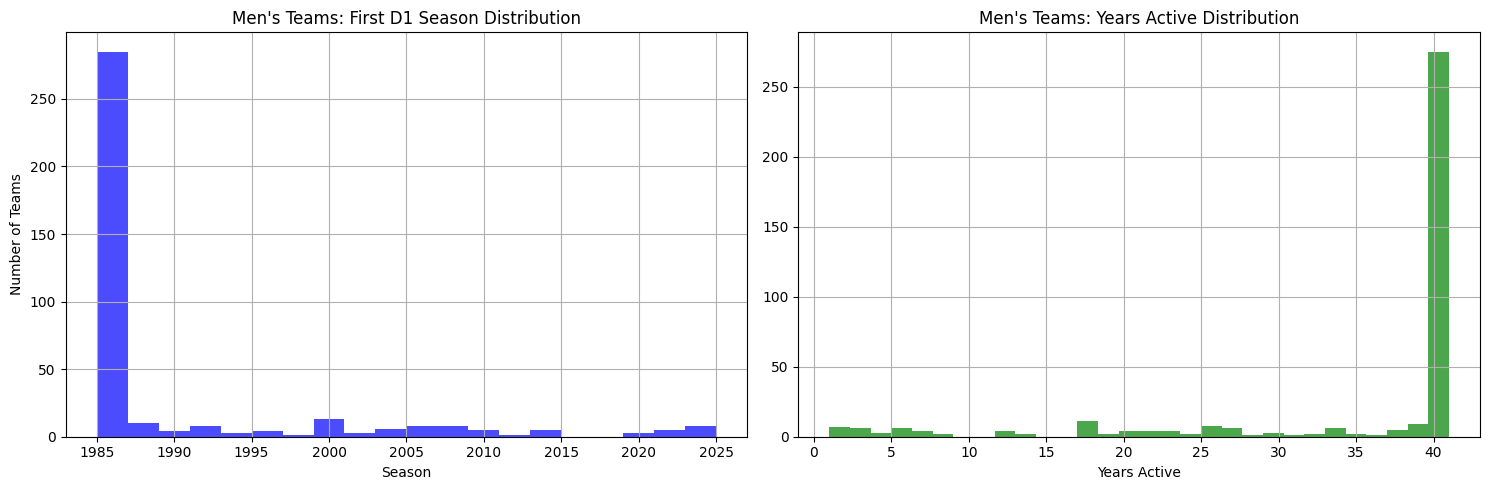

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Men's teams by first season
men_teams["FirstD1Season"].hist(bins=20, ax=axes[0], alpha=0.7, color="blue")
axes[0].set_title("Men's Teams: First D1 Season Distribution")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Number of Teams")

# Years active distribution
men_teams["YearsActive"].hist(bins=30, ax=axes[1], alpha=0.7, color="green")
axes[1].set_title("Men's Teams: Years Active Distribution")
axes[1].set_xlabel("Years Active")

plt.tight_layout()
plt.show()

Most of the teams participating in the tournaments for th past 40 years have been there from the start of the data.

## 3. Conference Analysis

In [46]:
conferences = pd.read_csv(data_dir / "Conferences.csv")
men_team_conferences = pd.read_csv(data_dir / "MTeamConferences.csv")
women_team_conferences = pd.read_csv(data_dir / "WTeamConferences.csv")

In [ ]:
print(f"Total conferences: {len(conferences)}")
print(f"Men's team-conference records: {len(men_team_conferences)}")
print(f"Women's team-conference records: {len(women_team_conferences)}")

Total conferences defined: 51
Men's team-conference records: 13388
Women's team-conference records: 9490


In [49]:
print("Some Conferences:")
conferences.sample(10)

Some Conferences:


,ConfAbbrev,Description
8,big_eight,Big Eight Conference
25,ivy,Ivy League
11,big_ten,Big Ten Conference
23,horizon,Horizon League
4,aec,America East Conference
1,a_ten,Atlantic 10 Conference
49,wac,Western Athletic Conference
31,mvc,Missouri Valley Conference
29,metro,Metropolitan Collegiate Athletic Conference
47,swac,Southwest Athletic Conference


In [51]:
men_team_conferences.sample(10)

,Season,TeamID,ConfAbbrev
12762,2024,1207,big_east
10918,2019,1136,nec
4194,1999,1168,big_west
12954,2024,1406,caa
6737,2007,1116,sec
10995,2019,1214,big_south
11206,2019,1429,mwc
5392,2002,1450,pac_ten
8843,2013,1165,ivy
12142,2022,1311,southland


In [54]:
conf_by_season = men_team_conferences.groupby("Season")["ConfAbbrev"].nunique()
teams_by_season = men_team_conferences.groupby("Season")["TeamID"].nunique()

In [55]:
print(f"\nMen's Conference Evolution:")
print(f"Season range: {men_team_conferences['Season'].min()} - {men_team_conferences['Season'].max()}")
print(f"Peak number of conferences in a season: {conf_by_season.max()} (Season {conf_by_season.idxmax()})")
print(f"Peak number of teams in a season: {teams_by_season.max()} (Season {teams_by_season.idxmax()})")


Men's Conference Evolution:
Season range: 1985 - 2025
Peak number of conferences in a season: 34 (Season 1991)
Peak number of teams in a season: 364 (Season 2025)


In [56]:
conf_counts = men_team_conferences["ConfAbbrev"].value_counts()
print(f"\nTop 10 Most Represented Conferences (Men's - by team-seasons):")
top_confs = conf_counts.head(10)
for conf, count in top_confs.items():
    conf_name = (
        conferences[conferences["ConfAbbrev"] == conf]["Description"].iloc[0]
        if conf in conferences["ConfAbbrev"].values
        else "Unknown"
    )
    print(f"{conf:12} ({conf_name[:30]:<30}): {count:4} team-seasons")


Top 10 Most Represented Conferences (Men's - by team-seasons):
a_ten        (Atlantic 10 Conference        ):  508 team-seasons
sec          (Southeastern Conference       ):  506 team-seasons
big_east     (Big East Conference           ):  488 team-seasons
big_ten      (Big Ten Conference            ):  483 team-seasons
mac          (Mid-American Conference       ):  467 team-seasons
acc          (Atlantic Coast Conference     ):  463 team-seasons
sun_belt     (Sun Belt Conference           ):  444 team-seasons
southland    (Southland Conference          ):  437 team-seasons
meac         (Mid-Eastern Athletic Conferenc):  428 team-seasons
southern     (Southern Conference           ):  427 team-seasons


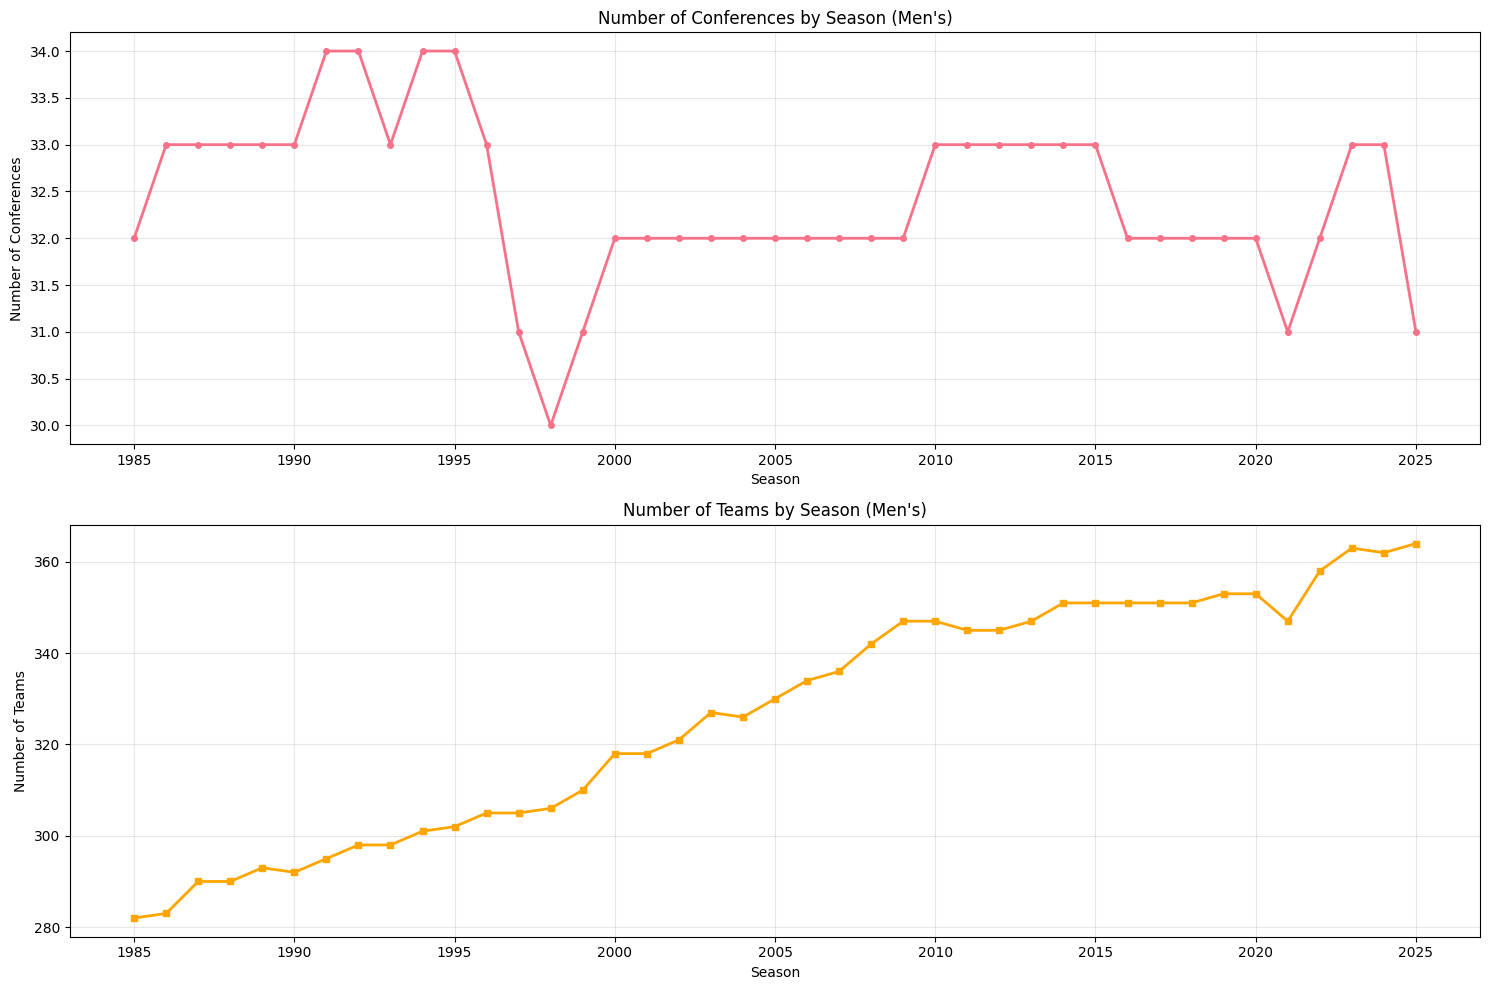

In [58]:
# Conference evolution visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Number of conferences per season
conf_by_season.plot(ax=axes[0], marker="o", linewidth=2, markersize=4)
axes[0].set_title("Number of Conferences by Season (Men's)")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Number of Conferences")
axes[0].grid(True, alpha=0.3)

# Number of teams per season
teams_by_season.plot(ax=axes[1], marker="s", linewidth=2, markersize=4, color="orange")
axes[1].set_title("Number of Teams by Season (Men's)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Number of Teams")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
print(f"\nConference Membership Analysis:")
team_conf_changes = men_team_conferences.groupby("TeamID")["ConfAbbrev"].nunique()
print(f"Teams that never changed conferences: {(team_conf_changes == 1).sum()}")
print(f"Teams that changed conferences: {(team_conf_changes > 1).sum()}")
print(f"Maximum conference changes by a team: {team_conf_changes.max() - 1}")

most_changes = team_conf_changes.sort_values(ascending=False).head(5)
print(f"\nTeams with most conference changes:")
for team_id, conf_count in most_changes.items():
    team_name = (
        men_teams[men_teams["TeamID"] == team_id]["TeamName"].iloc[0]
        if team_id in men_teams["TeamID"].values
        else "Unknown"
    )
    confs = men_team_conferences[men_team_conferences["TeamID"] == team_id]["ConfAbbrev"].unique()
    print(f"{team_name:20} (ID: {team_id}): {conf_count} conferences - {', '.join(confs)}")


Conference Membership Analysis:
Teams that never changed conferences: 136
Teams that changed conferences: 244
Maximum conference changes by a team: 6

Teams with most conference changes:
UCF                  (ID: 1416): 7 conferences - ind, asc, sun_belt, a_sun, cusa, aac, big_twelve
Chicago St           (ID: 1152): 6 conferences - ind, ecc, mid_cont, gwc, wac, nec
Southern Utah        (ID: 1381): 6 conferences - ind, awc, mid_cont, summit, big_sky, wac
UTRGV                (ID: 1410): 6 conferences - ind, asc, sun_belt, gwc, wac, southland
UT San Antonio       (ID: 1427): 6 conferences - ind, a_sun, southland, wac, cusa, aac


In [60]:
conf_by_season = women_team_conferences.groupby("Season")["ConfAbbrev"].nunique()
teams_by_season = women_team_conferences.groupby("Season")["TeamID"].nunique()

In [ ]:
print(f"\nWomen's Conference Evolution:")
print(f"Season range: {women_team_conferences['Season'].min()} - {women_team_conferences['Season'].max()}")
print(f"Peak number of conferences in a season: {conf_by_season.max()} (Season {conf_by_season.idxmax()})")
print(f"Peak number of teams in a season: {teams_by_season.max()} (Season {teams_by_season.idxmax()})")


Men's Conference Evolution:
Season range: 1998 - 2025
Peak number of conferences in a season: 33 (Season 2010)
Peak number of teams in a season: 362 (Season 2025)


In [62]:
conf_counts = women_team_conferences["ConfAbbrev"].value_counts()
print(f"\nTop 10 Most Represented Conferences (Women's - by team-seasons):")
top_confs = conf_counts.head(10)
for conf, count in top_confs.items():
    conf_name = (
        conferences[conferences["ConfAbbrev"] == conf]["Description"].iloc[0]
        if conf in conferences["ConfAbbrev"].values
        else "Unknown"
    )
    print(f"{conf:12} ({conf_name[:30]:<30}): {count:4} team-seasons")


Top 10 Most Represented Conferences (Women's - by team-seasons):
a_ten        (Atlantic 10 Conference        ):  379 team-seasons
sec          (Southeastern Conference       ):  364 team-seasons
big_east     (Big East Conference           ):  359 team-seasons
cusa         (Conference USA                ):  358 team-seasons
acc          (Atlantic Coast Conference     ):  353 team-seasons
big_ten      (Big Ten Conference            ):  348 team-seasons
mac          (Mid-American Conference       ):  343 team-seasons
southland    (Southland Conference          ):  325 team-seasons
sun_belt     (Sun Belt Conference           ):  324 team-seasons
big_twelve   (Big 12 Conference             ):  318 team-seasons


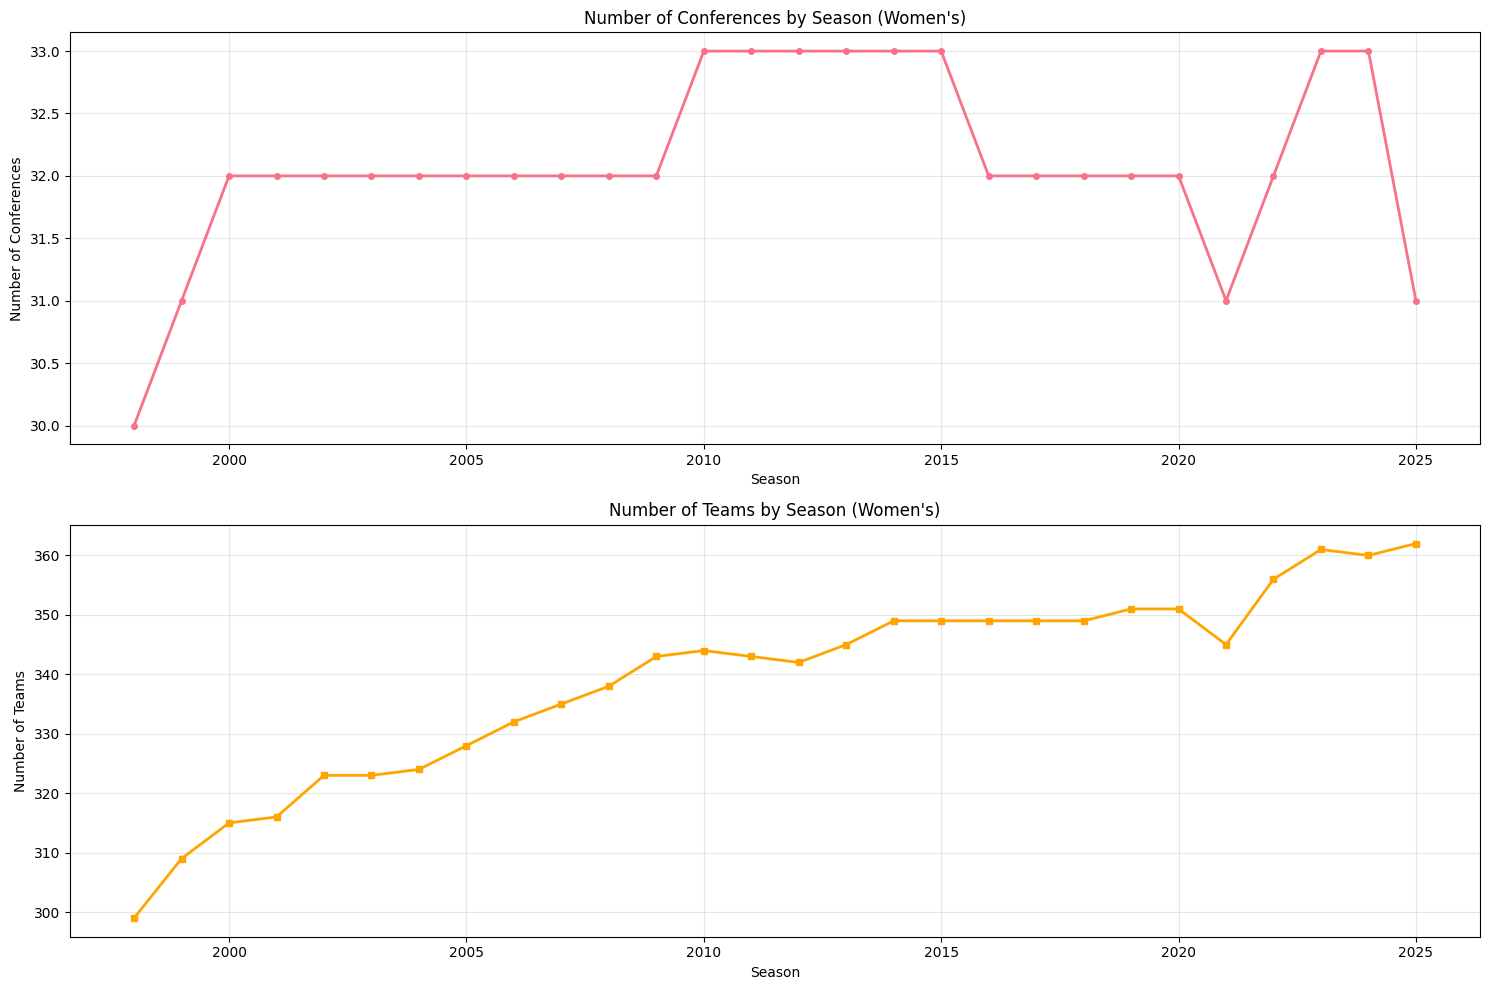

In [63]:
# Conference evolution visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Number of conferences per season
conf_by_season.plot(ax=axes[0], marker="o", linewidth=2, markersize=4)
axes[0].set_title("Number of Conferences by Season (Women's)")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Number of Conferences")
axes[0].grid(True, alpha=0.3)

# Number of teams per season
teams_by_season.plot(ax=axes[1], marker="s", linewidth=2, markersize=4, color="orange")
axes[1].set_title("Number of Teams by Season (Women's)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Number of Teams")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
print(f"\nConference Membership Analysis:")
team_conf_changes = women_team_conferences.groupby("TeamID")["ConfAbbrev"].nunique()
print(f"Teams that never changed conferences: {(team_conf_changes == 1).sum()}")
print(f"Teams that changed conferences: {(team_conf_changes > 1).sum()}")
print(f"Maximum conference changes by a team: {team_conf_changes.max() - 1}")

most_changes = team_conf_changes.sort_values(ascending=False).head(5)
print(f"\nTeams with most conference changes:")
for team_id, conf_count in most_changes.items():
    team_name = (
        women_teams[women_teams["TeamID"] == team_id]["TeamName"].iloc[0]
        if team_id in women_teams["TeamID"].values
        else "Unknown"
    )
    confs = women_team_conferences[women_team_conferences["TeamID"] == team_id]["ConfAbbrev"].unique()
    print(f"{team_name:20} (ID: {team_id}): {conf_count} conferences - {', '.join(confs)}")


Conference Membership Analysis:
Teams that never changed conferences: 190
Teams that changed conferences: 179
Maximum conference changes by a team: 4

Teams with most conference changes:
UTRGV                (ID: 3410): 5 conferences - sun_belt, ind, gwc, wac, southland
Chicago St           (ID: 3152): 5 conferences - mid_cont, ind, gwc, wac, nec
UT San Antonio       (ID: 3427): 4 conferences - southland, wac, cusa, aac
Utah                 (ID: 3428): 4 conferences - wac, mwc, pac_twelve, big_twelve
Cincinnati           (ID: 3153): 4 conferences - cusa, big_east, aac, big_twelve


## 4. Season Structure and Timeline Analysis

In [75]:
men_seasons = pd.read_csv(data_dir / "MSeasons.csv")
women_seasons = pd.read_csv(data_dir / "WSeasons.csv")

men_seasons["DayZero"] = pd.to_datetime(men_seasons["DayZero"])
women_seasons["DayZero"] = pd.to_datetime(women_seasons["DayZero"])

In [76]:
men_seasons

,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1985,1984-10-29,East,West,Midwest,Southeast
1,1986,1985-10-28,East,Midwest,Southeast,West
2,1987,1986-10-27,East,Southeast,Midwest,West
3,1988,1987-11-02,East,Midwest,Southeast,West
4,1989,1988-10-31,East,West,Midwest,Southeast
5,1990,1989-10-30,East,Midwest,Southeast,West
6,1991,1990-10-29,East,Southeast,Midwest,West
7,1992,1991-11-04,East,West,Midwest,Southeast
8,1993,1992-11-02,East,Midwest,Southeast,West
9,1994,1993-11-01,East,Southeast,Midwest,West


In [77]:
women_seasons

,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1998,1997-10-27,East,Midwest,Mideast,West
1,1999,1998-10-26,East,Mideast,Midwest,West
2,2000,1999-11-01,East,Midwest,Mideast,West
3,2001,2000-10-30,East,Midwest,Mideast,West
4,2002,2001-10-29,East,West,Mideast,Midwest
5,2003,2002-11-04,East,West,Mideast,Midwest
6,2004,2003-11-03,East,Mideast,Midwest,West
7,2005,2004-11-01,Chattanooga,Tempe,KansasCity,Philadelphia
8,2006,2005-10-31,Albuquerque,Cleveland,Bridgeport,San Antonio
9,2007,2006-10-30,Dallas,Dayton,Fresno,Greensboro


In [78]:
print("Season Information:")
print(f"Men's seasons available: {len(men_seasons)}")
print(f"Women's seasons available: {len(women_seasons)}")
print(f"Men's season range: {men_seasons['Season'].min()} - {men_seasons['Season'].max()}")
print(f"Women's season range: {women_seasons['Season'].min()} - {women_seasons['Season'].max()}")

Season Information:
Men's seasons available: 41
Women's seasons available: 28
Men's season range: 1985 - 2025
Women's season range: 1998 - 2025


In [86]:
print(f"\nTournament Regions Analysis:")
region_cols = ["RegionW", "RegionX", "RegionY", "RegionZ"]
all_seasons = pd.concat((men_seasons, women_seasons))
for col in region_cols:
    unique_regions = all_seasons[col].unique()
    print(f"{col}: {len(unique_regions)} unique values - {', '.join(unique_regions)}")


Tournament Regions Analysis:
RegionW: 17 unique values - East, Atlanta, Albuquerque, NA1, Chattanooga, Dallas, Greensboro, Berkeley, Dayton, DesMoines, Bridgeport, Lincoln, Albany, Alamo, Greenville1, Albany1, Birmingham2
RegionX: 24 unique values - West, Midwest, Southeast, South, Phoenix, Chicago, Oakland, NA2, Mideast, Tempe, Cleveland, Dayton, Spokane, Trenton, Memphis, Fresno, Norfolk, Stanford, Dallas, OklahomaCity, Hemisfair, Seattle4, Portland4, Birmingham3
RegionY: 22 unique values - Midwest, Southeast, South, EastRutherford, Austin, Minneapolis, NA3, Mideast, KansasCity, Bridgeport, Fresno, NewOrleans, OklahomaCity, Dayton, Kingston, Louisville, Greensboro, Lexington, Mercado, Greenville2, Albany2, Spokane1
RegionZ: 26 unique values - Southeast, West, South, StLouis, Syracuse, WashingtonDC, Southwest, NA4, Midwest, Philadelphia, San Antonio, Greensboro, OklahomaCity, Raleigh, Sacramento, Spokane, NotreDame, SiouxFalls, Stockton, Lexington, Portland, RiverWalk, Wichita, Seatt

In [87]:
men_seasons["StartMonth"] = men_seasons["DayZero"].dt.month
men_seasons["StartDay"] = men_seasons["DayZero"].dt.day

women_seasons["StartMonth"] = women_seasons["DayZero"].dt.month
women_seasons["StartDay"] = women_seasons["DayZero"].dt.day

print(f"\nSeason Start Timing Analysis:")
print(f"Most common start months: {women_seasons['StartMonth'].value_counts().head()}")
print(f"Average start day: {men_seasons['StartDay'].mean():.1f}")


Season Start Timing Analysis:
Most common start months: StartMonth
11    18
10    10
Name: count, dtype: int64
Average start day: 15.2


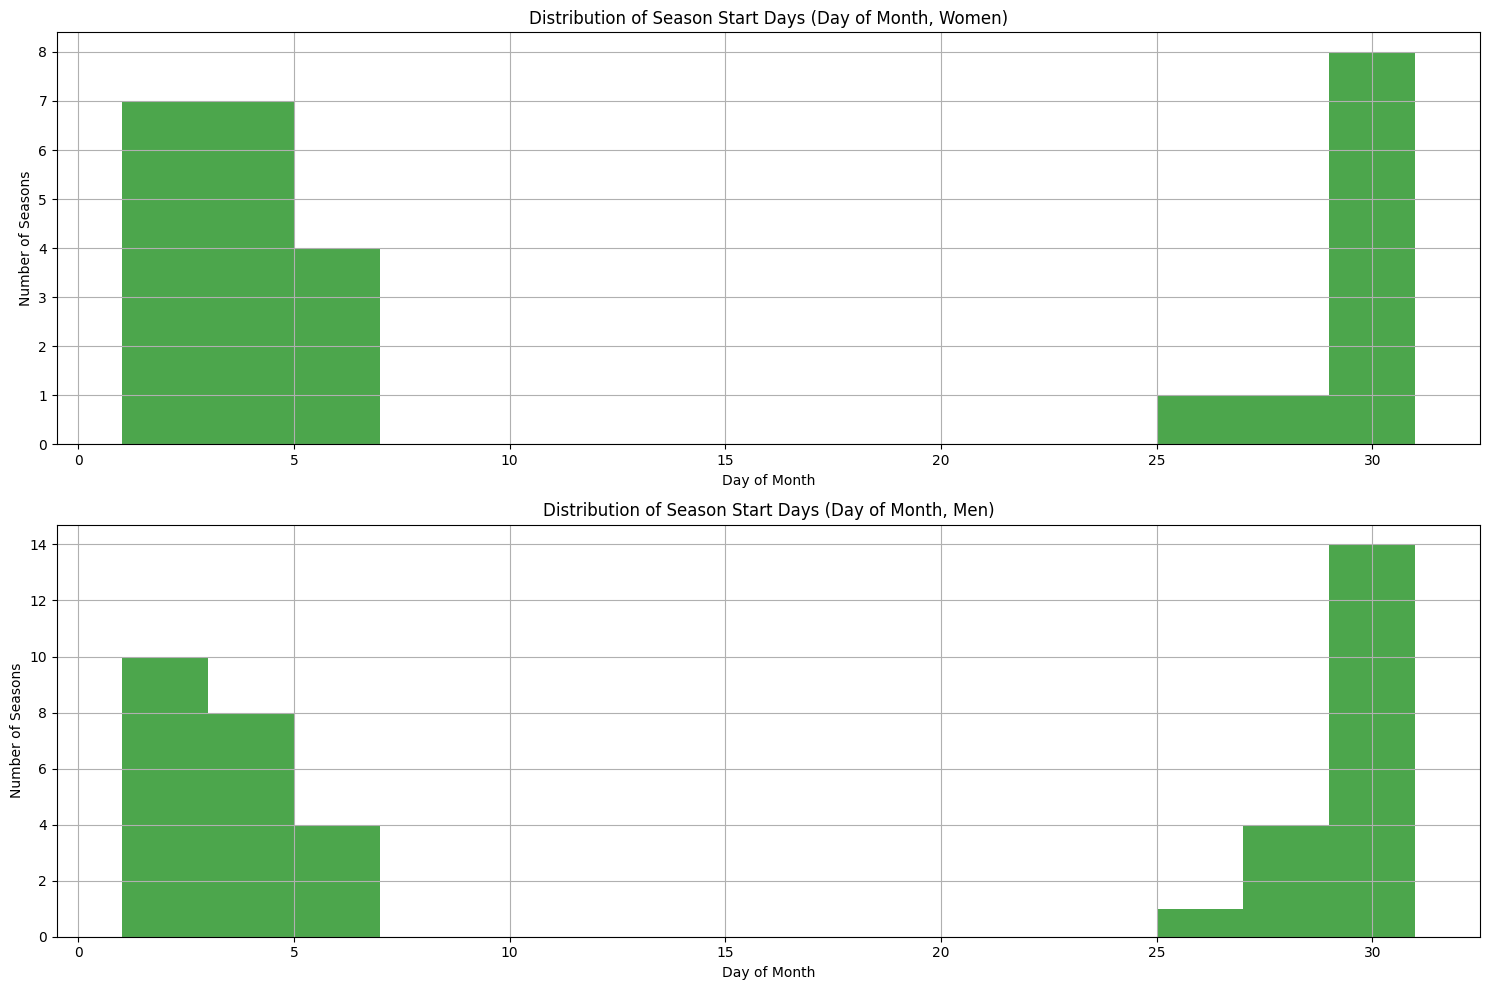

In [88]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

women_seasons["StartDay"].hist(bins=15, ax=axes[0], alpha=0.7, color="green")
axes[0].set_title("Distribution of Season Start Days (Day of Month, Women)")
axes[0].set_xlabel("Day of Month")
axes[0].set_ylabel("Number of Seasons")

men_seasons["StartDay"].hist(bins=15, ax=axes[1], alpha=0.7, color="green")
axes[1].set_title("Distribution of Season Start Days (Day of Month, Men)")
axes[1].set_xlabel("Day of Month")
axes[1].set_ylabel("Number of Seasons")

plt.tight_layout()
plt.show()

## 5. Game Results Analysis

In [93]:
men_regular = pd.read_csv(data_dir / "MRegularSeasonCompactResults.csv")
women_regular = pd.read_csv(data_dir / "WRegularSeasonCompactResults.csv")
men_tourney = pd.read_csv(data_dir / "MNCAATourneyCompactResults.csv")
women_tourney = pd.read_csv(data_dir / "WNCAATourneyCompactResults.csv")

In [94]:
print("Game Results Overview:")
print(f"Men's Regular Season Games: {len(men_regular):,}")
print(f"Women's Regular Season Games: {len(women_regular):,}")
print(f"Men's Tournament Games: {len(men_tourney):,}")
print(f"Women's Tournament Games: {len(women_tourney):,}")

Game Results Overview:
Men's Regular Season Games: 192,930
Women's Regular Season Games: 137,028
Men's Tournament Games: 2,518
Women's Tournament Games: 1,650


In [95]:
print(f"\nGame Data Structure:")
print(f"Regular season columns: {list(men_regular.columns)}")
print(f"Tournament columns: {list(men_tourney.columns)}")


Game Data Structure:
Regular season columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT']
Tournament columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT']


In [96]:
print(f"\nSeason Coverage:")
print(f"Men's regular season: {men_regular['Season'].min()} - {men_regular['Season'].max()}")
print(f"Women's regular season: {women_regular['Season'].min()} - {women_regular['Season'].max()}")
print(f"Men's tournament: {men_tourney['Season'].min()} - {men_tourney['Season'].max()}")
print(f"Women's tournament: {women_tourney['Season'].min()} - {women_tourney['Season'].max()}")


Season Coverage:
Men's regular season: 1985 - 2025
Women's regular season: 1998 - 2025
Men's tournament: 1985 - 2024
Women's tournament: 1998 - 2024


In [116]:
games_per_season = men_regular.groupby("Season").size()
tourney_games_per_season = men_tourney.groupby("Season").size()

print(f"\nGames Per Season Statistics (Men's):")
print(
    f"Regular season - Mean: {games_per_season.mean():.0f}, Min: {games_per_season.min()}, Max: {games_per_season.max()}"
)
print(
    f"Tournament - Mean: {tourney_games_per_season.mean():.0f}, Min: {tourney_games_per_season.min()}, Max: {tourney_games_per_season.max()}"
)

# Scoring analysis
print(f"\nScoring Analysis (Men's Regular Season):")
men_regular["TotalPoints"] = men_regular["WScore"] + men_regular["LScore"]
men_regular["PointDiff"] = men_regular["WScore"] - men_regular["LScore"]

print(f"Average total points per game: {men_regular['TotalPoints'].mean():.1f}")
print(f"Average point differential: {men_regular['PointDiff'].mean():.1f}")
print(f"Median point differential: {men_regular['PointDiff'].median():.1f}")
print(f"Largest victory margin: {men_regular['PointDiff'].max()} points")

# Overtime games
overtime_games = men_regular[men_regular["NumOT"] > 0]
print(f"\nOvertime Analysis:")
print(
    f"Regular season games with overtime: {len(overtime_games):,} ({len(overtime_games) / len(men_regular) * 100:.2f}%)"
)
print(f"Maximum overtimes in a game: {men_regular['NumOT'].max()}")

tourney_overtime = men_tourney[men_tourney["NumOT"] > 0]
print(
    f"Tournament games with overtime: {len(tourney_overtime):,} ({len(tourney_overtime) / len(men_tourney) * 100:.2f}%)"
)

# Home court advantage analysis
print(f"\nHome Court Advantage Analysis:")
home_games = men_regular[men_regular["WLoc"] == "H"]
away_games = men_regular[men_regular["WLoc"] == "A"]
neutral_games = men_regular[men_regular["WLoc"] == "N"]

print(f"Home games (winner at home): {len(home_games):,} ({len(home_games) / len(men_regular) * 100:.1f}%)")
print(f"Away games (winner on road): {len(away_games):,} ({len(away_games) / len(men_regular) * 100:.1f}%)")
print(f"Neutral site games: {len(neutral_games):,} ({len(neutral_games) / len(men_regular) * 100:.1f}%)")

# Calculate actual home advantage
total_home_neutral = len(home_games) + len(neutral_games)
home_win_rate = len(home_games) / (len(home_games) + len(away_games)) * 100
print(f"Home team win rate (excluding neutral): {home_win_rate:.1f}%")


Games Per Season Statistics (Men's):
Regular season - Mean: 4706, Min: 3737, Max: 5641
Tournament - Mean: 65, Min: 63, Max: 67

Scoring Analysis (Men's Regular Season):
Average total points per game: 141.6
Average point differential: 12.1
Median point differential: 10.0
Largest victory margin: 94 points

Overtime Analysis:
Regular season games with overtime: 7,847 (4.07%)
Maximum overtimes in a game: 6
Tournament games with overtime: 150 (5.96%)

Home Court Advantage Analysis:
Home games (winner at home): 113,922 (59.0%)
Away games (winner on road): 59,247 (30.7%)
Neutral site games: 19,761 (10.2%)
Home team win rate (excluding neutral): 65.8%


In [117]:
women_games_per_season = women_regular.groupby("Season").size()
women_tourney_games_per_season = women_tourney.groupby("Season").size()

print(f"\nGames Per Season Statistics (Women's):")
print(
    f"Regular season - Mean: {women_games_per_season.mean():.0f}, Min: {women_games_per_season.min()}, Max: {women_games_per_season.max()}"
)
print(
    f"Tournament - Mean: {women_tourney_games_per_season.mean():.0f}, Min: {women_tourney_games_per_season.min()}, Max: {women_tourney_games_per_season.max()}"
)

# Scoring analysis
print(f"\nScoring Analysis (Women's Regular Season):")
women_regular["TotalPoints"] = women_regular["WScore"] + women_regular["LScore"]
women_regular["PointDiff"] = women_regular["WScore"] - women_regular["LScore"]

print(f"Average total points per game: {women_regular['TotalPoints'].mean():.1f}")
print(f"Average point differential: {women_regular['PointDiff'].mean():.1f}")
print(f"Median point differential: {women_regular['PointDiff'].median():.1f}")
print(f"Largest victory margin: {women_regular['PointDiff'].max()} points")

# Overtime games
women_overtime_games = women_regular[women_regular["NumOT"] > 0]
print(f"\nOvertime Analysis:")
print(
    f"Regular season games with overtime: {len(women_overtime_games):,} ({len(women_overtime_games) / len(women_regular) * 100:.2f}%)"
)
print(f"Maximum overtimes in a game: {women_regular['NumOT'].max()}")

women_tourney_overtime = women_tourney[women_tourney["NumOT"] > 0]
print(
    f"Tournament games with overtime: {len(women_tourney_overtime):,} ({len(women_tourney_overtime) / len(women_tourney) * 100:.2f}%)"
)

# Home court advantage analysis
print(f"\nHome Court Advantage Analysis:")
women_home_games = women_regular[women_regular["WLoc"] == "H"]
women_away_games = women_regular[women_regular["WLoc"] == "A"]
women_neutral_games = women_regular[women_regular["WLoc"] == "N"]

print(
    f"Home games (winner at home): {len(women_home_games):,} ({len(women_home_games) / len(women_regular) * 100:.1f}%)"
)
print(
    f"Away games (winner on road): {len(women_away_games):,} ({len(women_away_games) / len(women_regular) * 100:.1f}%)"
)
print(f"Neutral site games: {len(women_neutral_games):,} ({len(women_neutral_games) / len(women_regular) * 100:.1f}%)")

# Calculate actual home advantage
women_home_win_rate = len(women_home_games) / (len(women_home_games) + len(women_away_games)) * 100
print(f"Home team win rate (excluding neutral): {women_home_win_rate:.1f}%")


Games Per Season Statistics (Women's):
Regular season - Mean: 4894, Min: 3556, Max: 5444
Tournament - Mean: 63, Min: 63, Max: 67

Scoring Analysis (Women's Regular Season):
Average total points per game: 129.4
Average point differential: 14.4
Median point differential: 12.0
Largest victory margin: 108 points

Overtime Analysis:
Regular season games with overtime: 4,651 (3.39%)
Maximum overtimes in a game: 5
Tournament games with overtime: 37 (2.24%)

Home Court Advantage Analysis:
Home games (winner at home): 77,593 (56.6%)
Away games (winner on road): 49,225 (35.9%)
Neutral site games: 10,210 (7.5%)
Home team win rate (excluding neutral): 61.2%


In [119]:
print(
    f"Average scoring difference (Men vs Women): {men_regular['TotalPoints'].mean() - women_regular['TotalPoints'].mean():.1f} points"
)
print(
    f"Home advantage difference: {home_win_rate - women_home_win_rate:.1f}% (Men stronger)"
    if home_win_rate > women_home_win_rate
    else f"Home advantage difference: {women_home_win_rate - home_win_rate:.1f}% (Women stronger)"
)
print(
    f"Overtime frequency difference: {len(overtime_games) / len(men_regular) * 100 - len(women_overtime_games) / len(women_regular) * 100:.2f}%"
)

Average scoring difference (Men vs Women): 12.2 points
Home advantage difference: 4.6% (Men stronger)
Overtime frequency difference: 0.67%


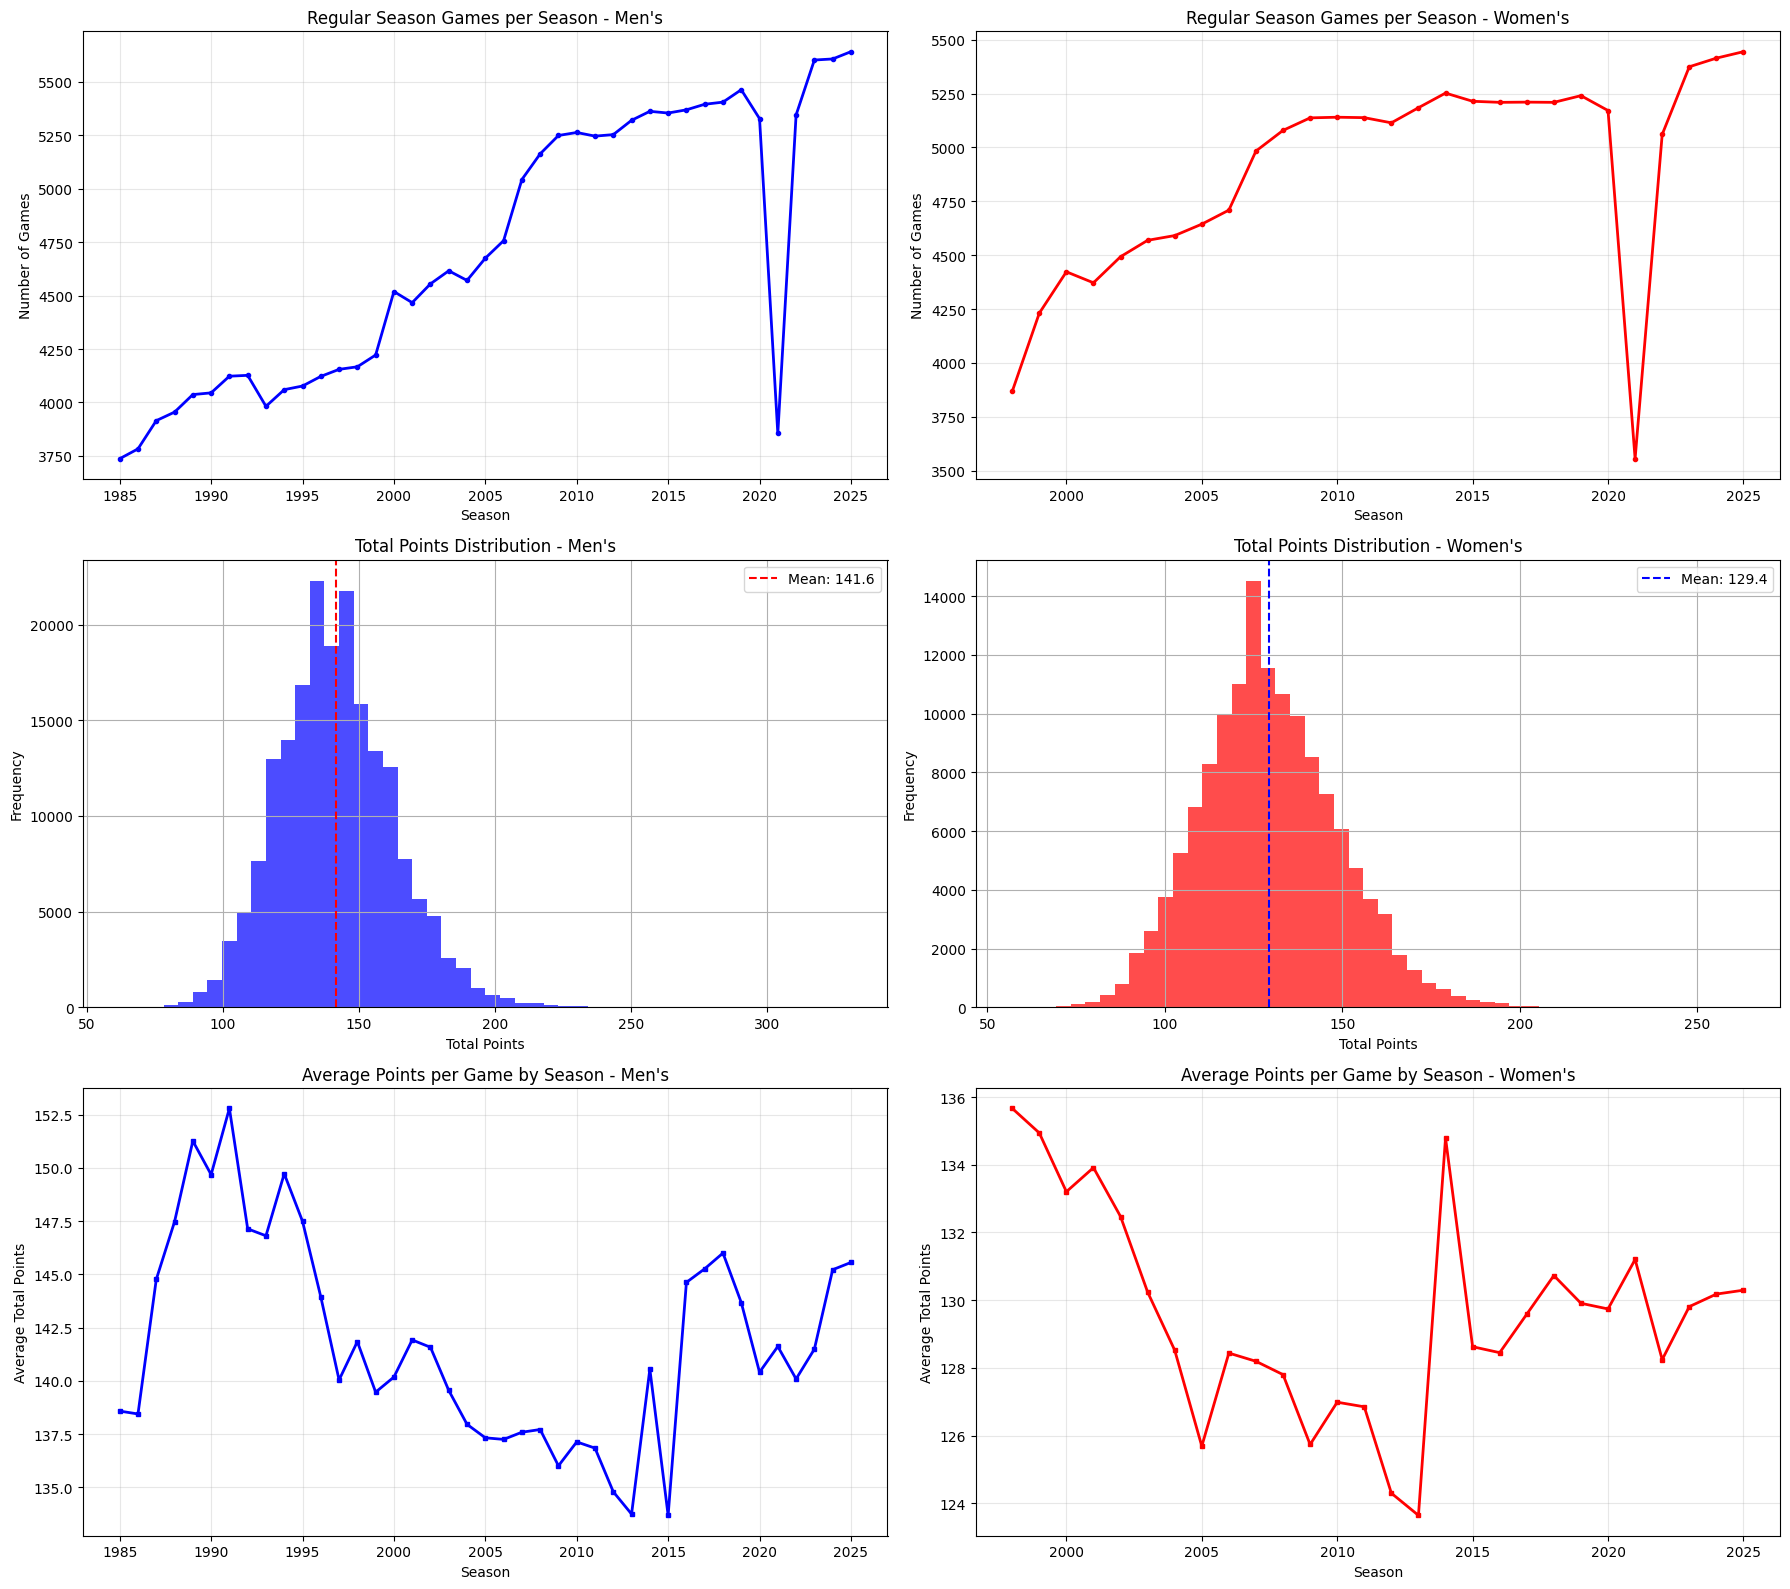

In [120]:
# Visualization - Side by side comparison
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# Games per season trend comparison
games_per_season.plot(ax=axes[0, 0], marker="o", linewidth=2, markersize=3, color="blue", label="Men")
axes[0, 0].set_title("Regular Season Games per Season - Men's")
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Number of Games")
axes[0, 0].grid(True, alpha=0.3)

women_games_per_season.plot(ax=axes[0, 1], marker="o", linewidth=2, markersize=3, color="red", label="Women")
axes[0, 1].set_title("Regular Season Games per Season - Women's")
axes[0, 1].set_xlabel("Season")
axes[0, 1].set_ylabel("Number of Games")
axes[0, 1].grid(True, alpha=0.3)

# Point distribution comparison
men_regular["TotalPoints"].hist(bins=50, ax=axes[1, 0], alpha=0.7, color="blue")
axes[1, 0].set_title("Total Points Distribution - Men's")
axes[1, 0].set_xlabel("Total Points")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].axvline(
    men_regular["TotalPoints"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {men_regular['TotalPoints'].mean():.1f}",
)
axes[1, 0].legend()

women_regular["TotalPoints"].hist(bins=50, ax=axes[1, 1], alpha=0.7, color="red")
axes[1, 1].set_title("Total Points Distribution - Women's")
axes[1, 1].set_xlabel("Total Points")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].axvline(
    women_regular["TotalPoints"].mean(),
    color="blue",
    linestyle="--",
    label=f"Mean: {women_regular['TotalPoints'].mean():.1f}",
)
axes[1, 1].legend()

# Scoring trends over time comparison
scoring_by_season = men_regular.groupby("Season")["TotalPoints"].mean()
women_scoring_by_season = women_regular.groupby("Season")["TotalPoints"].mean()

scoring_by_season.plot(ax=axes[2, 0], marker="s", linewidth=2, markersize=3, color="blue")
axes[2, 0].set_title("Average Points per Game by Season - Men's")
axes[2, 0].set_xlabel("Season")
axes[2, 0].set_ylabel("Average Total Points")
axes[2, 0].grid(True, alpha=0.3)

women_scoring_by_season.plot(ax=axes[2, 1], marker="s", linewidth=2, markersize=3, color="red")
axes[2, 1].set_title("Average Points per Game by Season - Women's")
axes[2, 1].set_xlabel("Season")
axes[2, 1].set_ylabel("Average Total Points")
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The dip in count of games from 2020 - 2021 could be an irregularity (covid) to take into account when training and evaluation our models.

### 5.1 Point Distribution Analysis

In [113]:
def analyze_point_distribution(game_data, title_prefix="", show_plots=True):
    """
    Comprehensive analysis of point distribution for winning and losing teams

    Parameters:
    game_data: DataFrame with columns 'WScore', 'LScore'
    title_prefix: String to add to plot titles (e.g., "Men's" or "Women's")
    show_plots: Boolean to control whether to display visualizations

    Returns:
    Dictionary with analysis results
    """

    # Ensure required columns exist and calculate derived columns if needed
    if "PointDiff" not in game_data.columns:
        game_data = game_data.copy()
        game_data["PointDiff"] = game_data["WScore"] - game_data["LScore"]
        game_data["TotalPoints"] = game_data["WScore"] + game_data["LScore"]

    # Create separate datasets for analysis
    winning_scores = game_data["WScore"]
    losing_scores = game_data["LScore"]

    print(f"=== {title_prefix.upper()} POINT DISTRIBUTION ANALYSIS ===\n")

    print(f"Winning Team Statistics:")
    print(f"Mean: {winning_scores.mean():.1f}")
    print(f"Median: {winning_scores.median():.1f}")
    print(f"Min: {winning_scores.min()}")
    print(f"Max: {winning_scores.max()}")
    print(f"Std Dev: {winning_scores.std():.1f}")

    print(f"\nLosing Team Statistics:")
    print(f"Mean: {losing_scores.mean():.1f}")
    print(f"Median: {losing_scores.median():.1f}")
    print(f"Min: {losing_scores.min()}")
    print(f"Max: {losing_scores.max()}")
    print(f"Std Dev: {losing_scores.std():.1f}")

    print(f"\nPoint Spread Analysis:")
    print(f"Average winning margin: {game_data['PointDiff'].mean():.1f}")
    print(f"Median winning margin: {game_data['PointDiff'].median():.1f}")
    print(f"Margin std deviation: {game_data['PointDiff'].std():.1f}")
    print(f"Margin range: {game_data['PointDiff'].min():.0f} - {game_data['PointDiff'].max():.0f}")
    print(f"Total games analyzed: {len(game_data):,}")

    # Store results for return
    results = {
        "winning_mean": winning_scores.mean(),
        "losing_mean": losing_scores.mean(),
        "winning_std": winning_scores.std(),
        "losing_std": losing_scores.std(),
        "avg_margin": game_data["PointDiff"].mean(),
        "margin_std": game_data["PointDiff"].std(),
        "margin_median": game_data["PointDiff"].median(),
        "margin_q1": game_data["PointDiff"].quantile(0.25),
        "margin_q3": game_data["PointDiff"].quantile(0.75),
        "total_games": len(game_data),
    }

    if show_plots:
        # Create comprehensive visualization
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))

        # 1. Overlapping histograms
        axes[0, 0].hist(
            [winning_scores, losing_scores],
            bins=50,
            alpha=0.7,
            label=["Winning Teams", "Losing Teams"],
            color=["green", "red"],
            edgecolor="black",
            linewidth=0.5,
        )
        axes[0, 0].set_title(f"{title_prefix} Point Distribution: Winners vs Losers", fontsize=14)
        axes[0, 0].set_xlabel("Points Scored")
        axes[0, 0].set_ylabel("Frequency")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Side-by-side box plots
        box_data = [winning_scores, losing_scores]
        bp = axes[0, 1].boxplot(box_data, labels=["Winners", "Losers"], patch_artist=True)
        bp["boxes"][0].set_facecolor("lightgreen")
        bp["boxes"][1].set_facecolor("lightcoral")
        axes[0, 1].set_title(f"{title_prefix} Point Distribution Box Plots", fontsize=14)
        axes[0, 1].set_ylabel("Points Scored")
        axes[0, 1].grid(True, alpha=0.3)

        # 3. Density plots
        winning_scores.plot.density(ax=axes[1, 0], color="green", linewidth=2, label="Winners")
        losing_scores.plot.density(ax=axes[1, 0], color="red", linewidth=2, label="Losers")
        axes[1, 0].set_title(f"{title_prefix} Point Distribution Density Curves", fontsize=14)
        axes[1, 0].set_xlabel("Points Scored")
        axes[1, 0].set_ylabel("Density")
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # 4. Cumulative distribution
        winning_scores_sorted = np.sort(winning_scores)
        losing_scores_sorted = np.sort(losing_scores)
        winning_cdf = np.arange(1, len(winning_scores_sorted) + 1) / len(winning_scores_sorted)
        losing_cdf = np.arange(1, len(losing_scores_sorted) + 1) / len(losing_scores_sorted)

        axes[1, 1].plot(winning_scores_sorted, winning_cdf, color="green", linewidth=2, label="Winners")
        axes[1, 1].plot(losing_scores_sorted, losing_cdf, color="red", linewidth=2, label="Losers")
        axes[1, 1].set_title(f"{title_prefix} Cumulative Distribution Functions", fontsize=14)
        axes[1, 1].set_xlabel("Points Scored")
        axes[1, 1].set_ylabel("Cumulative Probability")
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        # 5. Margin distribution histogram
        axes[2, 0].hist(game_data["PointDiff"], bins=40, alpha=0.8, color="orange", edgecolor="black", linewidth=0.5)
        axes[2, 0].axvline(
            game_data["PointDiff"].mean(),
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean: {game_data['PointDiff'].mean():.1f}",
        )
        axes[2, 0].axvline(
            game_data["PointDiff"].median(),
            color="blue",
            linestyle="--",
            linewidth=2,
            label=f"Median: {game_data['PointDiff'].median():.1f}",
        )
        axes[2, 0].set_title(f"{title_prefix} Victory Margin Distribution", fontsize=14)
        axes[2, 0].set_xlabel("Margin of Victory (points)")
        axes[2, 0].set_ylabel("Frequency")
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)

        # 6. Margin box plot with quartiles
        margin_bp = axes[2, 1].boxplot(
            [game_data["PointDiff"]], labels=["Victory Margin"], patch_artist=True, showmeans=True
        )
        axes[2, 1].set_title(f"{title_prefix} Victory Margin Box Plot", fontsize=14)
        axes[2, 1].set_ylabel("Margin of Victory (points)")
        axes[2, 1].grid(True, alpha=0.3)

        # Add statistics text to margin box plot
        q1 = game_data["PointDiff"].quantile(0.25)
        q3 = game_data["PointDiff"].quantile(0.75)
        axes[2, 1].text(
            1.2,
            game_data["PointDiff"].median(),
            f"Q2: {game_data['PointDiff'].median():.1f}",
            verticalalignment="center",
        )
        axes[2, 1].text(1.2, q1, f"Q1: {q1:.1f}", verticalalignment="center")
        axes[2, 1].text(1.2, q3, f"Q3: {q3:.1f}", verticalalignment="center")

        plt.tight_layout()
        plt.show()

    # Additional analysis: High and low scoring games
    print(f"\n=== EXTREME SCORING ANALYSIS ===")

    # High scoring games (both teams)
    high_scoring_threshold = 80
    high_scoring_winners = game_data[game_data["WScore"] >= high_scoring_threshold]
    high_scoring_losers = game_data[game_data["LScore"] >= high_scoring_threshold]

    print(
        f"Games where winner scored ≥{high_scoring_threshold}: {len(high_scoring_winners)} ({len(high_scoring_winners) / len(game_data) * 100:.1f}%)"
    )
    print(
        f"Games where loser scored ≥{high_scoring_threshold}: {len(high_scoring_losers)} ({len(high_scoring_losers) / len(game_data) * 100:.1f}%)"
    )

    # Low scoring games
    low_scoring_threshold = 50
    low_scoring_winners = game_data[game_data["WScore"] <= low_scoring_threshold]
    low_scoring_losers = game_data[game_data["LScore"] <= low_scoring_threshold]

    print(
        f"Games where winner scored ≤{low_scoring_threshold}: {len(low_scoring_winners)} ({len(low_scoring_winners) / len(game_data) * 100:.1f}%)"
    )
    print(
        f"Games where loser scored ≤{low_scoring_threshold}: {len(low_scoring_losers)} ({len(low_scoring_losers) / len(game_data) * 100:.1f}%)"
    )

    # Very close games (small margins)
    close_games = game_data[game_data["PointDiff"] <= 3]
    print(f"Games decided by ≤3 points: {len(close_games)} ({len(close_games) / len(game_data) * 100:.1f}%)")

    # Blowout games (large margins)
    blowout_games = game_data[game_data["PointDiff"] >= 20]
    print(f"Games decided by ≥20 points: {len(blowout_games)} ({len(blowout_games) / len(game_data) * 100:.1f}%)")

    # Store additional results
    results.update(
        {
            "high_scoring_winners_pct": len(high_scoring_winners) / len(game_data) * 100,
            "high_scoring_losers_pct": len(high_scoring_losers) / len(game_data) * 100,
            "low_scoring_winners_pct": len(low_scoring_winners) / len(game_data) * 100,
            "low_scoring_losers_pct": len(low_scoring_losers) / len(game_data) * 100,
            "close_games_pct": len(close_games) / len(game_data) * 100,
            "blowout_games_pct": len(blowout_games) / len(game_data) * 100,
        }
    )

    # Score ranges analysis
    print(f"\n=== SCORE RANGE ANALYSIS ===")
    score_ranges = [(0, 49), (50, 59), (60, 69), (70, 79), (80, 89), (90, 99), (100, float("inf"))]

    for low, high in score_ranges:
        if high == float("inf"):
            winners_in_range = len(game_data[game_data["WScore"] >= low])
            losers_in_range = len(game_data[game_data["LScore"] >= low])
            range_str = f"{low}+"
        else:
            winners_in_range = len(game_data[(game_data["WScore"] >= low) & (game_data["WScore"] <= high)])
            losers_in_range = len(game_data[(game_data["LScore"] >= low) & (game_data["LScore"] <= high)])
            range_str = f"{low}-{high}"

        print(
            f"Points {range_str}: Winners={winners_in_range:5d} ({winners_in_range / len(game_data) * 100:4.1f}%), Losers={losers_in_range:5d} ({losers_in_range / len(game_data) * 100:4.1f}%)"
        )
    return results

=== MEN'S BASKETBALL POINT DISTRIBUTION ANALYSIS ===

Winning Team Statistics:
Mean: 76.9
Median: 76.0
Min: 34
Max: 186
Std Dev: 11.8

Losing Team Statistics:
Mean: 64.8
Median: 64.0
Min: 20
Max: 150
Std Dev: 11.2

Point Spread Analysis:
Average winning margin: 12.1
Median winning margin: 10.0
Margin std deviation: 9.4
Margin range: 1 - 94
Total games analyzed: 192,930


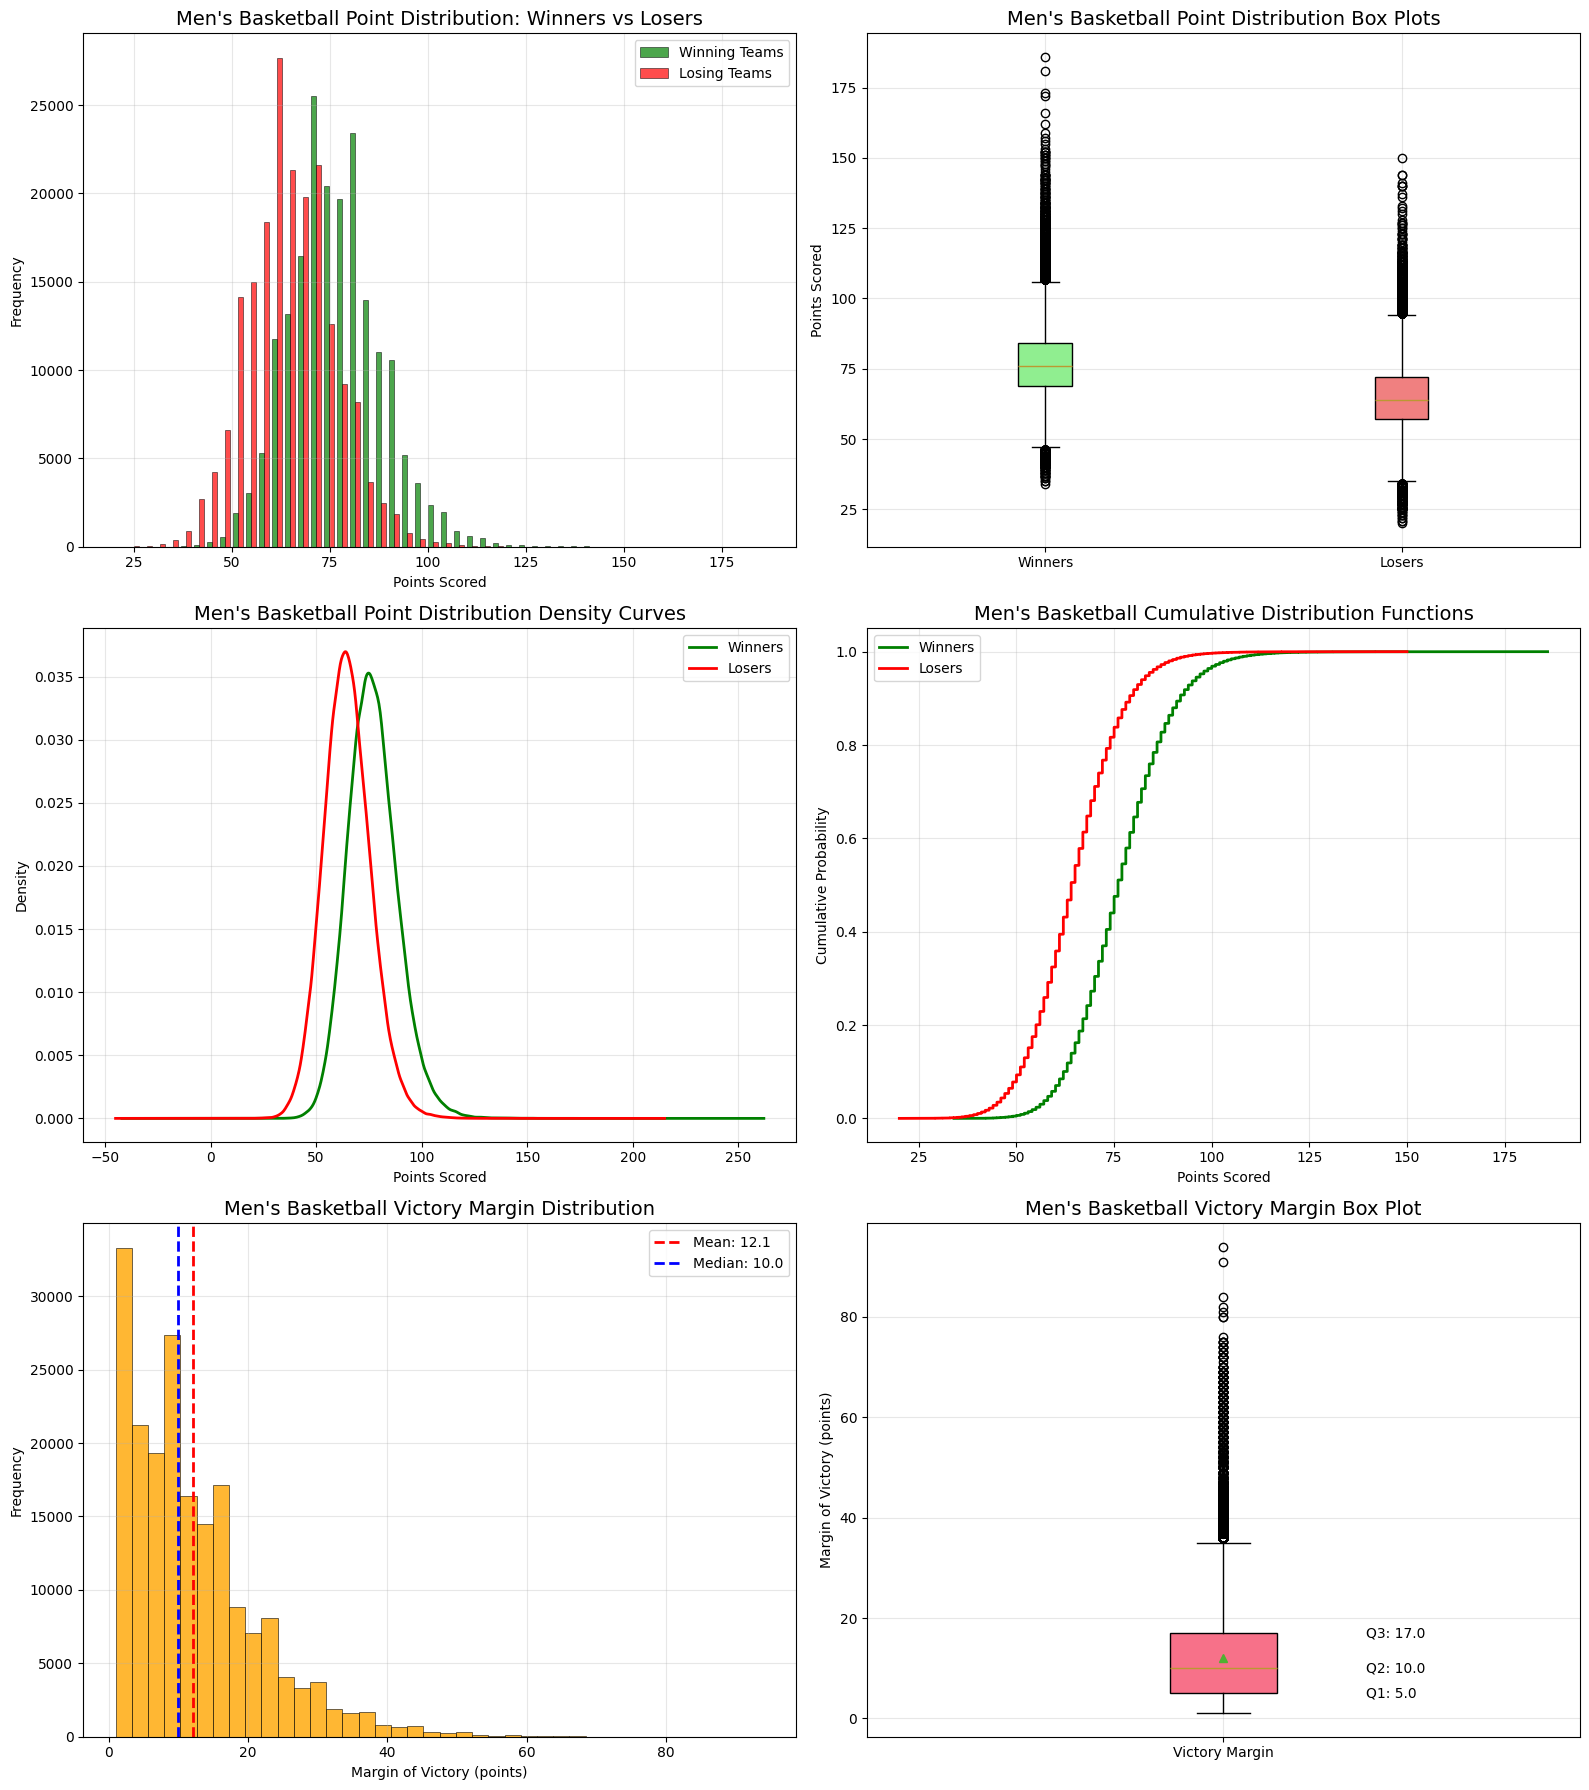


=== EXTREME SCORING ANALYSIS ===
Games where winner scored ≥80: 74726 (38.7%)
Games where loser scored ≥80: 18178 (9.4%)
Games where winner scored ≤50: 1206 (0.6%)
Games where loser scored ≤50: 17981 (9.3%)
Games decided by ≤3 points: 33301 (17.3%)
Games decided by ≥20 points: 34929 (18.1%)

=== SCORE RANGE ANALYSIS ===
Points 0-49: Winners=  896 ( 0.5%), Losers=15027 ( 7.8%)
Points 50-59: Winners=10262 ( 5.3%), Losers=47543 (24.6%)
Points 60-69: Winners=41398 (21.5%), Losers=68760 (35.6%)
Points 70-79: Winners=65648 (34.0%), Losers=43422 (22.5%)
Points 80-89: Winners=48420 (25.1%), Losers=14352 ( 7.4%)
Points 90-99: Winners=19345 (10.0%), Losers= 3091 ( 1.6%)
Points 100+: Winners= 6961 ( 3.6%), Losers=  735 ( 0.4%)




In [109]:
men_results = analyze_point_distribution(men_regular, "Men's Basketball", show_plots=True)

=== WOMEN'S BASKETBALL POINT DISTRIBUTION ANALYSIS ===

Winning Team Statistics:
Mean: 71.9
Median: 71.0
Min: 30
Max: 140
Std Dev: 11.4

Losing Team Statistics:
Mean: 57.5
Median: 57.0
Min: 11
Max: 130
Std Dev: 10.8

Point Spread Analysis:
Average winning margin: 14.4
Median winning margin: 12.0
Margin std deviation: 11.0
Margin range: 1 - 108
Total games analyzed: 137,028


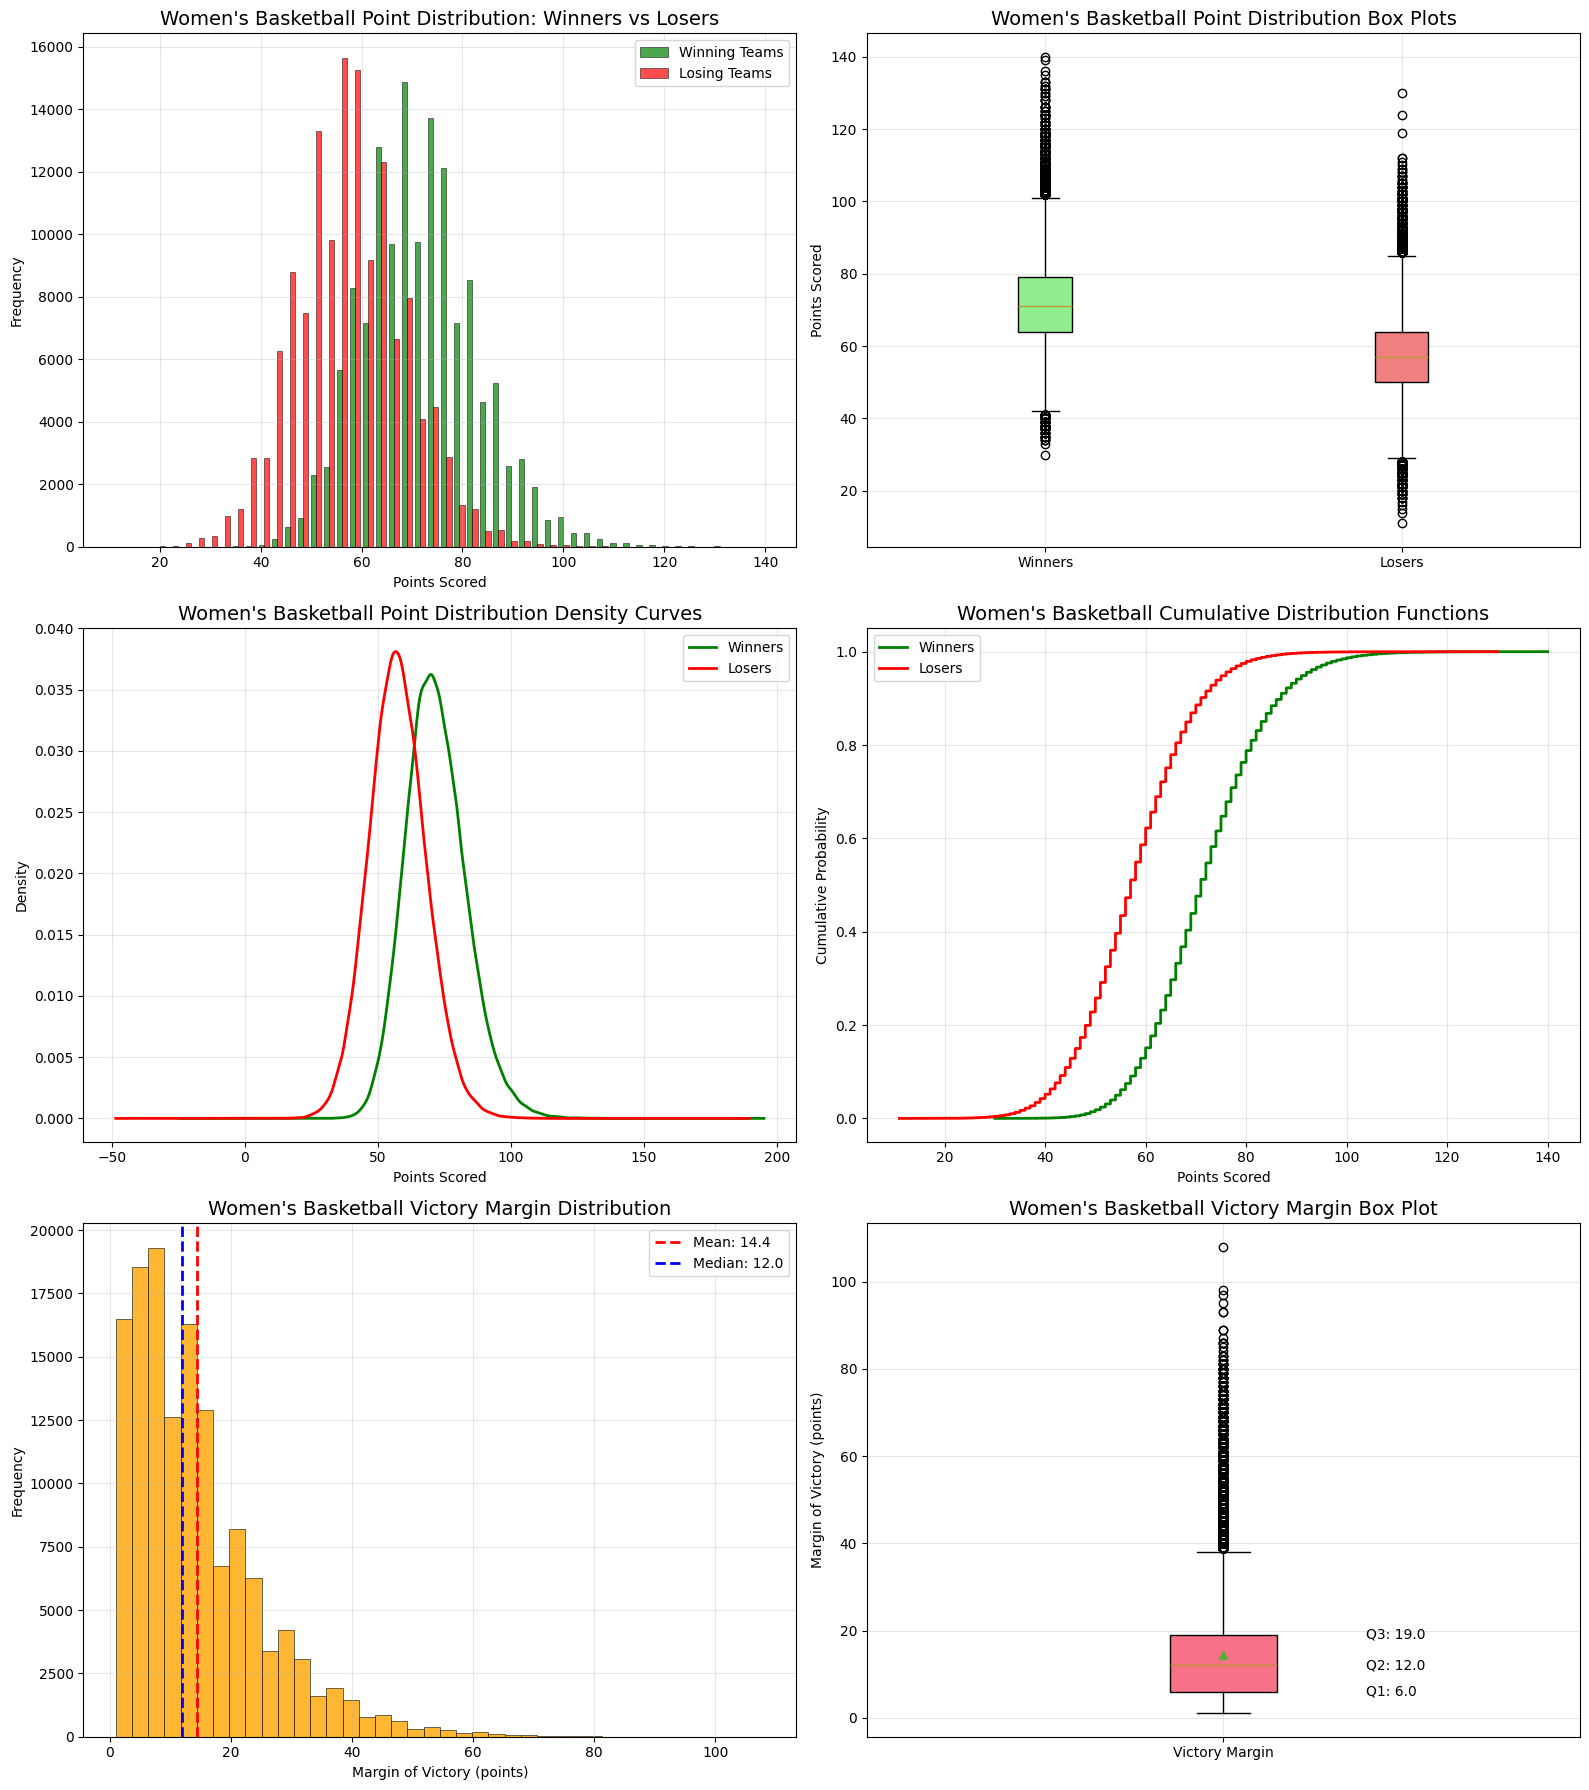


=== EXTREME SCORING ANALYSIS ===
Games where winner scored ≥80: 32531 (23.7%)
Games where loser scored ≥80: 3489 (2.5%)
Games where winner scored ≤50: 2537 (1.9%)
Games where loser scored ≤50: 35345 (25.8%)
Games decided by ≤3 points: 16484 (12.0%)
Games decided by ≥20 points: 34104 (24.9%)

=== SCORE RANGE ANALYSIS ===
Points 0-49: Winners= 1932 ( 1.4%), Losers=31229 (22.8%)
Points 50-59: Winners=15719 (11.5%), Losers=49075 (35.8%)
Points 60-69: Winners=42518 (31.0%), Losers=38744 (28.3%)
Points 70-79: Winners=44328 (32.3%), Losers=14491 (10.6%)
Points 80-89: Winners=23242 (17.0%), Losers= 2977 ( 2.2%)
Points 90-99: Winners= 7152 ( 5.2%), Losers=  444 ( 0.3%)
Points 100+: Winners= 2137 ( 1.6%), Losers=   68 ( 0.0%)


In [122]:
women_results = analyze_point_distribution(women_regular, "Women's Basketball", show_plots=True)

### 5.2 Home/Away Analysis

In [123]:
def analyze_home_advantage(regular_season_data, gender_name):
    """Analyze home court advantage with detailed statistics"""

    # Separate games by location
    home_games = regular_season_data[regular_season_data["WLoc"] == "H"]
    away_games = regular_season_data[regular_season_data["WLoc"] == "A"]
    neutral_games = regular_season_data[regular_season_data["WLoc"] == "N"]

    # Calculate win percentages
    total_games_with_location = len(home_games) + len(away_games)  # Exclude neutral
    home_win_pct = len(home_games) / total_games_with_location * 100
    away_win_pct = len(away_games) / total_games_with_location * 100

    # Calculate scoring differences
    home_avg_margin = home_games["PointDiff"].mean()
    away_avg_margin = away_games["PointDiff"].mean()
    neutral_avg_margin = neutral_games["PointDiff"].mean() if len(neutral_games) > 0 else 0

    # Calculate scoring averages
    home_avg_total_pts = home_games["TotalPoints"].mean()
    away_avg_total_pts = away_games["TotalPoints"].mean()
    neutral_avg_total_pts = neutral_games["TotalPoints"].mean() if len(neutral_games) > 0 else 0

    results = {
        "home_games": len(home_games),
        "away_games": len(away_games),
        "neutral_games": len(neutral_games),
        "home_win_pct": home_win_pct,
        "away_win_pct": away_win_pct,
        "home_avg_margin": home_avg_margin,
        "away_avg_margin": away_avg_margin,
        "neutral_avg_margin": neutral_avg_margin,
        "home_avg_total_pts": home_avg_total_pts,
        "away_avg_total_pts": away_avg_total_pts,
        "neutral_avg_total_pts": neutral_avg_total_pts,
        "home_games_data": home_games,
        "away_games_data": away_games,
        "neutral_games_data": neutral_games,
    }

    print(f"\n{gender_name} HOME COURT ADVANTAGE:")
    print(f"Home wins: {len(home_games):,} ({home_win_pct:.1f}%)")
    print(f"Away wins: {len(away_games):,} ({away_win_pct:.1f}%)")
    print(f"Neutral site: {len(neutral_games):,}")
    print(f"Home advantage: {home_win_pct - 50:.1f} percentage points")
    print(f"Average margin at home: {home_avg_margin:.1f} points")
    print(f"Average margin on road: {away_avg_margin:.1f} points")
    print(f"Scoring difference (home vs away): {home_avg_total_pts - away_avg_total_pts:.1f} points")

    return results

In [124]:
men_home_stats = analyze_home_advantage(men_regular, "MEN'S")


MEN'S HOME COURT ADVANTAGE:
Home wins: 113,922 (65.8%)
Away wins: 59,247 (34.2%)
Neutral site: 19,761
Home advantage: 15.8 percentage points
Average margin at home: 13.6 points
Average margin on road: 9.5 points
Scoring difference (home vs away): 1.5 points


In [125]:
women_home_stats = analyze_home_advantage(women_regular, "WOMEN'S")


WOMEN'S HOME COURT ADVANTAGE:
Home wins: 77,593 (61.2%)
Away wins: 49,225 (38.8%)
Neutral site: 10,210
Home advantage: 11.2 percentage points
Average margin at home: 15.9 points
Average margin on road: 12.2 points
Scoring difference (home vs away): 0.9 points


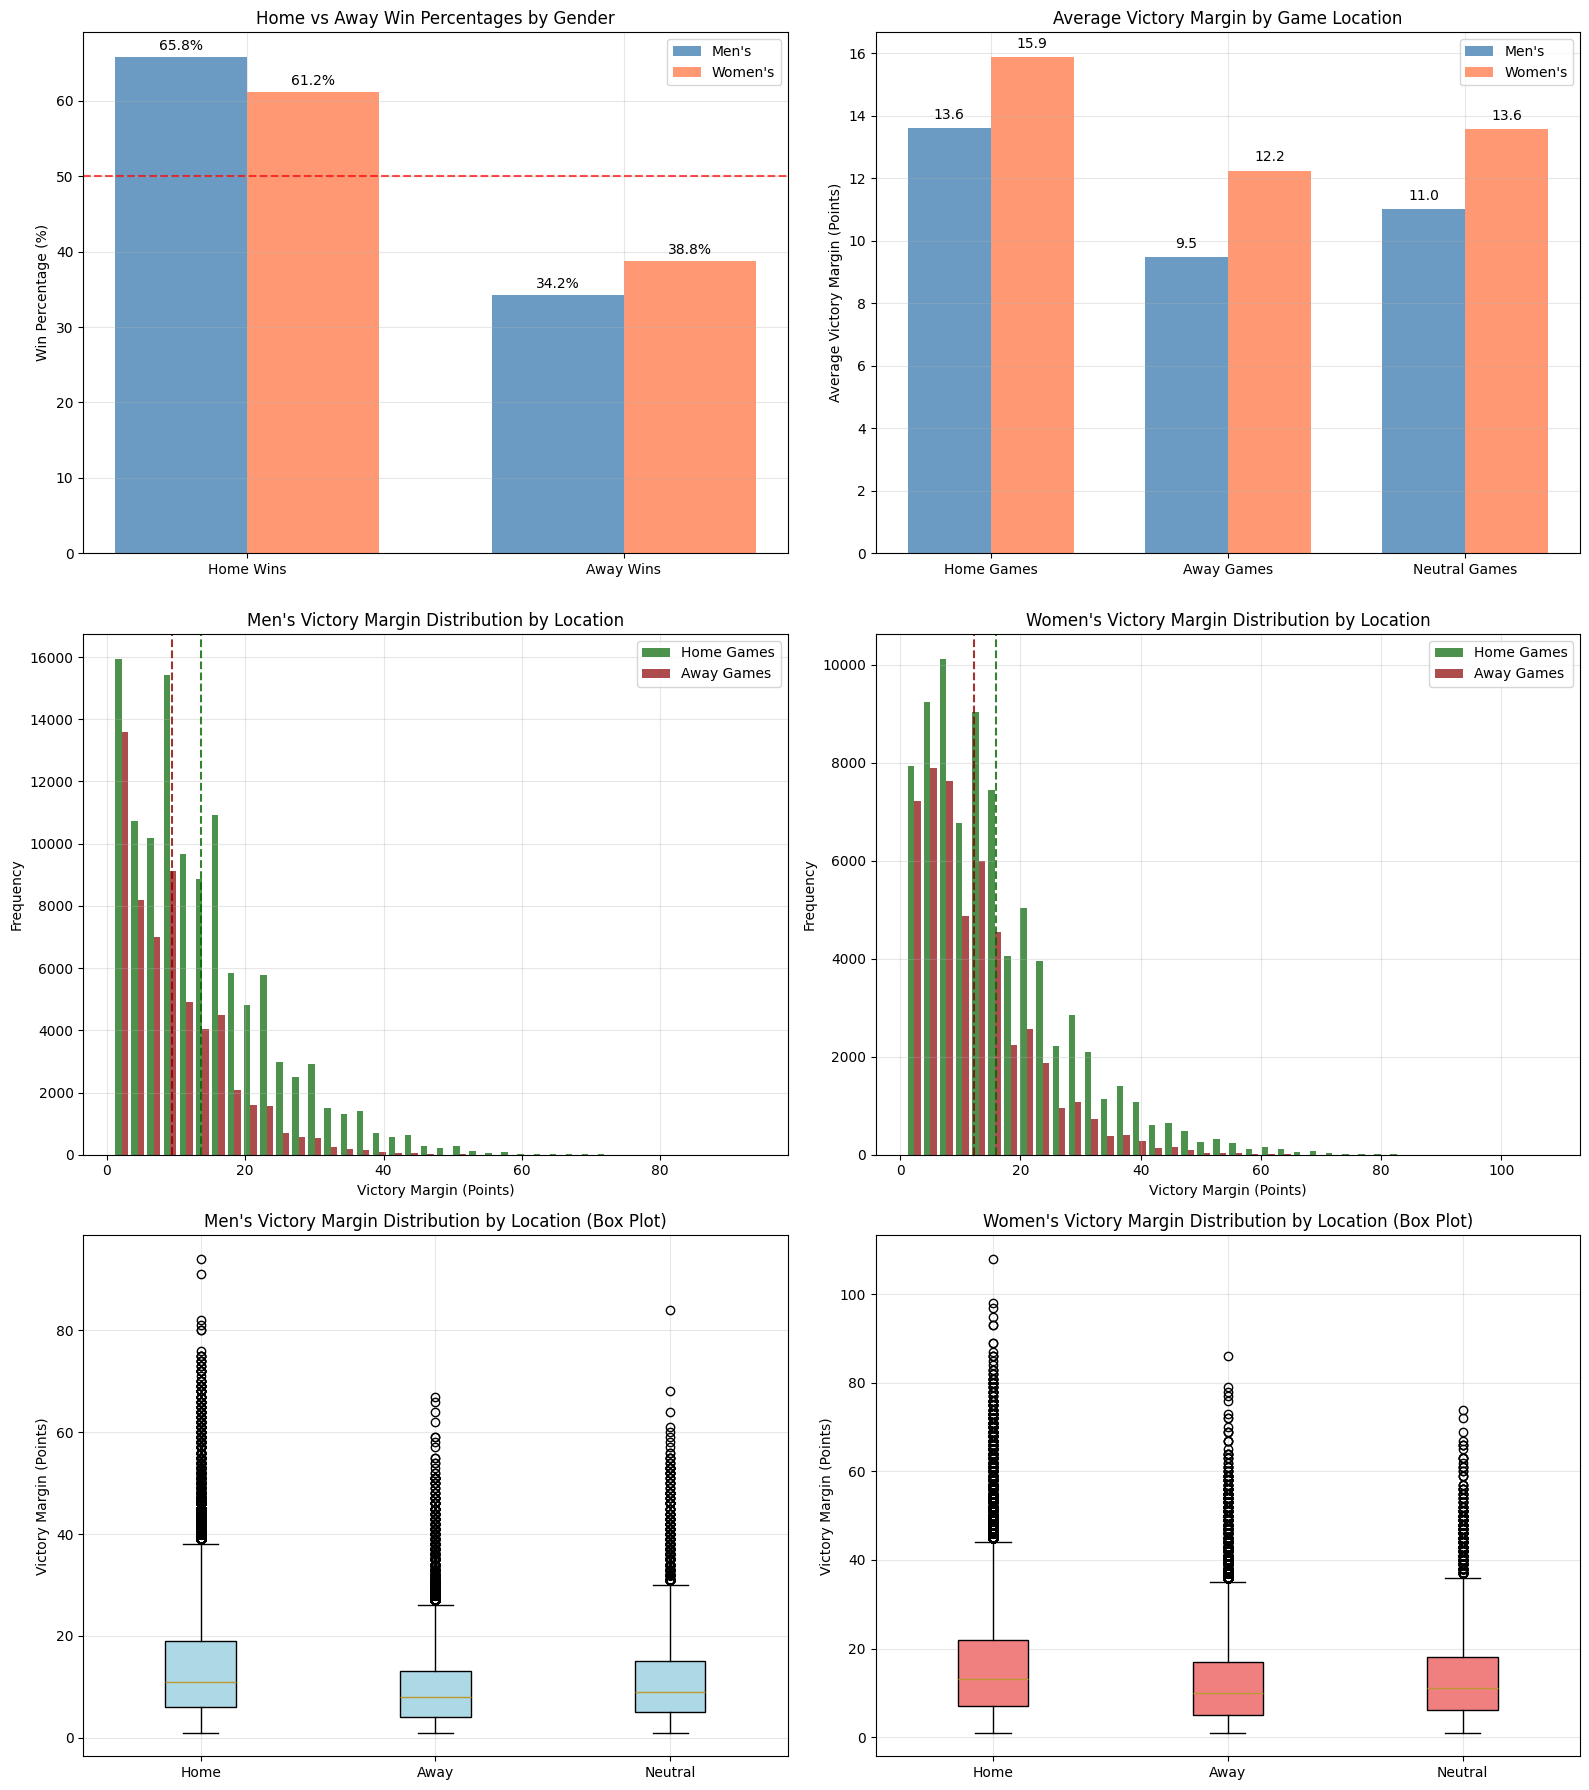

In [126]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Win Percentage Comparison
categories = ["Home Wins", "Away Wins"]
men_win_pcts = [men_home_stats["home_win_pct"], men_home_stats["away_win_pct"]]
women_win_pcts = [women_home_stats["home_win_pct"], women_home_stats["away_win_pct"]]

x = np.arange(len(categories))
width = 0.35

bars1 = axes[0, 0].bar(x - width / 2, men_win_pcts, width, label="Men's", color="steelblue", alpha=0.8)
bars2 = axes[0, 0].bar(x + width / 2, women_win_pcts, width, label="Women's", color="coral", alpha=0.8)

axes[0, 0].set_ylabel("Win Percentage (%)")
axes[0, 0].set_title("Home vs Away Win Percentages by Gender")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(categories)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=50, color="red", linestyle="--", alpha=0.7, label="Expected (50%)")

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2.0, height + 0.5, f"{height:.1f}%", ha="center", va="bottom", fontsize=10
    )
for bar in bars2:
    height = bar.get_height()
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2.0, height + 0.5, f"{height:.1f}%", ha="center", va="bottom", fontsize=10
    )

# 2. Victory Margin by Location
margin_categories = ["Home Games", "Away Games", "Neutral Games"]
men_margins = [
    men_home_stats["home_avg_margin"],
    men_home_stats["away_avg_margin"],
    men_home_stats["neutral_avg_margin"],
]
women_margins = [
    women_home_stats["home_avg_margin"],
    women_home_stats["away_avg_margin"],
    women_home_stats["neutral_avg_margin"],
]

x2 = np.arange(len(margin_categories))
bars3 = axes[0, 1].bar(x2 - width / 2, men_margins, width, label="Men's", color="steelblue", alpha=0.8)
bars4 = axes[0, 1].bar(x2 + width / 2, women_margins, width, label="Women's", color="coral", alpha=0.8)

axes[0, 1].set_ylabel("Average Victory Margin (Points)")
axes[0, 1].set_title("Average Victory Margin by Game Location")
axes[0, 1].set_xticks(x2)
axes[0, 1].set_xticklabels(margin_categories)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2.0, height + 0.2, f"{height:.1f}", ha="center", va="bottom", fontsize=10
    )
for bar in bars4:
    height = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2.0, height + 0.2, f"{height:.1f}", ha="center", va="bottom", fontsize=10
    )

# 3. Point Differential Distribution - Men's
axes[1, 0].hist(
    [men_home_stats["home_games_data"]["PointDiff"], men_home_stats["away_games_data"]["PointDiff"]],
    bins=40,
    alpha=0.7,
    label=["Home Games", "Away Games"],
    color=["darkgreen", "darkred"],
)
axes[1, 0].set_title("Men's Victory Margin Distribution by Location")
axes[1, 0].set_xlabel("Victory Margin (Points)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(men_home_stats["home_avg_margin"], color="darkgreen", linestyle="--", alpha=0.8)
axes[1, 0].axvline(men_home_stats["away_avg_margin"], color="darkred", linestyle="--", alpha=0.8)

# 4. Point Differential Distribution - Women's
axes[1, 1].hist(
    [women_home_stats["home_games_data"]["PointDiff"], women_home_stats["away_games_data"]["PointDiff"]],
    bins=40,
    alpha=0.7,
    label=["Home Games", "Away Games"],
    color=["darkgreen", "darkred"],
)
axes[1, 1].set_title("Women's Victory Margin Distribution by Location")
axes[1, 1].set_xlabel("Victory Margin (Points)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(women_home_stats["home_avg_margin"], color="darkgreen", linestyle="--", alpha=0.8)
axes[1, 1].axvline(women_home_stats["away_avg_margin"], color="darkred", linestyle="--", alpha=0.8)

# 5. Box plots of victory margins by location - Men's
box_data_men = [
    men_home_stats["home_games_data"]["PointDiff"],
    men_home_stats["away_games_data"]["PointDiff"],
    men_home_stats["neutral_games_data"]["PointDiff"] if len(men_home_stats["neutral_games_data"]) > 0 else [],
]

bp1 = axes[2, 0].boxplot(
    [d for d in box_data_men if len(d) > 0],
    labels=["Home", "Away", "Neutral"][: len([d for d in box_data_men if len(d) > 0])],
    patch_artist=True,
)
for patch in bp1["boxes"]:
    patch.set_facecolor("lightblue")
axes[2, 0].set_title("Men's Victory Margin Distribution by Location (Box Plot)")
axes[2, 0].set_ylabel("Victory Margin (Points)")
axes[2, 0].grid(True, alpha=0.3)

# 6. Box plots of victory margins by location - Women's
box_data_women = [
    women_home_stats["home_games_data"]["PointDiff"],
    women_home_stats["away_games_data"]["PointDiff"],
    women_home_stats["neutral_games_data"]["PointDiff"] if len(women_home_stats["neutral_games_data"]) > 0 else [],
]

bp2 = axes[2, 1].boxplot(
    [d for d in box_data_women if len(d) > 0],
    labels=["Home", "Away", "Neutral"][: len([d for d in box_data_women if len(d) > 0])],
    patch_artist=True,
)
for patch in bp2["boxes"]:
    patch.set_facecolor("lightcoral")
axes[2, 1].set_title("Women's Victory Margin Distribution by Location (Box Plot)")
axes[2, 1].set_ylabel("Victory Margin (Points)")
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
print(f"{'Metric':<30} {'Men':<15} {'Women':<15} {'Difference':<15}")
print("-" * 75)
print(
    f"{'Home Win %':<30} {men_home_stats['home_win_pct']:<15.1f} {women_home_stats['home_win_pct']:<15.1f} {men_home_stats['home_win_pct'] - women_home_stats['home_win_pct']:<15.1f}"
)
print(
    f"{'Home Advantage (pp)':<30} {men_home_stats['home_win_pct'] - 50:<15.1f} {women_home_stats['home_win_pct'] - 50:<15.1f} {(men_home_stats['home_win_pct'] - 50) - (women_home_stats['home_win_pct'] - 50):<15.1f}"
)
print(
    f"{'Avg Home Margin':<30} {men_home_stats['home_avg_margin']:<15.1f} {women_home_stats['home_avg_margin']:<15.1f} {men_home_stats['home_avg_margin'] - women_home_stats['home_avg_margin']:<15.1f}"
)
print(
    f"{'Avg Away Margin':<30} {men_home_stats['away_avg_margin']:<15.1f} {women_home_stats['away_avg_margin']:<15.1f} {men_home_stats['away_avg_margin'] - women_home_stats['away_avg_margin']:<15.1f}"
)

margin_diff_men = men_home_stats["home_avg_margin"] - men_home_stats["away_avg_margin"]
margin_diff_women = women_home_stats["home_avg_margin"] - women_home_stats["away_avg_margin"]
print(
    f"{'Home-Away Margin Diff':<30} {margin_diff_men:<15.1f} {margin_diff_women:<15.1f} {margin_diff_men - margin_diff_women:<15.1f}"
)

Metric                         Men             Women           Difference     
---------------------------------------------------------------------------
Home Win %                     65.8            61.2            4.6            
Home Advantage (pp)            15.8            11.2            4.6            
Avg Home Margin                13.6            15.9            -2.3           
Avg Away Margin                9.5             12.2            -2.8           
Home-Away Margin Diff          4.1             3.6             0.5            


According to the data it definitely seems to be an advantage to play at home.

### 5.3  Men's vs. Women's Basketball

Key Differences Summary:
Metric                    Men's        Women's      Difference     
----------------------------------------------------------------------
Avg Winner Score          76.9         71.9         +4.9           
Avg Loser Score           64.8         57.5         +7.3           
Avg Winning Margin        12.1         14.4         -2.3           
Winner Std Dev            11.8         11.4         +0.5           
Loser Std Dev             11.2         10.8         +0.4           
Close Games %             17.3         12.0         +5.2           
Blowout Games %           18.1         24.9         -6.8           
High Scoring Winners %    38.7         23.7         +15.0          
Low Scoring Winners %     0.6          1.9          -1.2           

Total Games: Men's = 192,930, Women's = 137,028


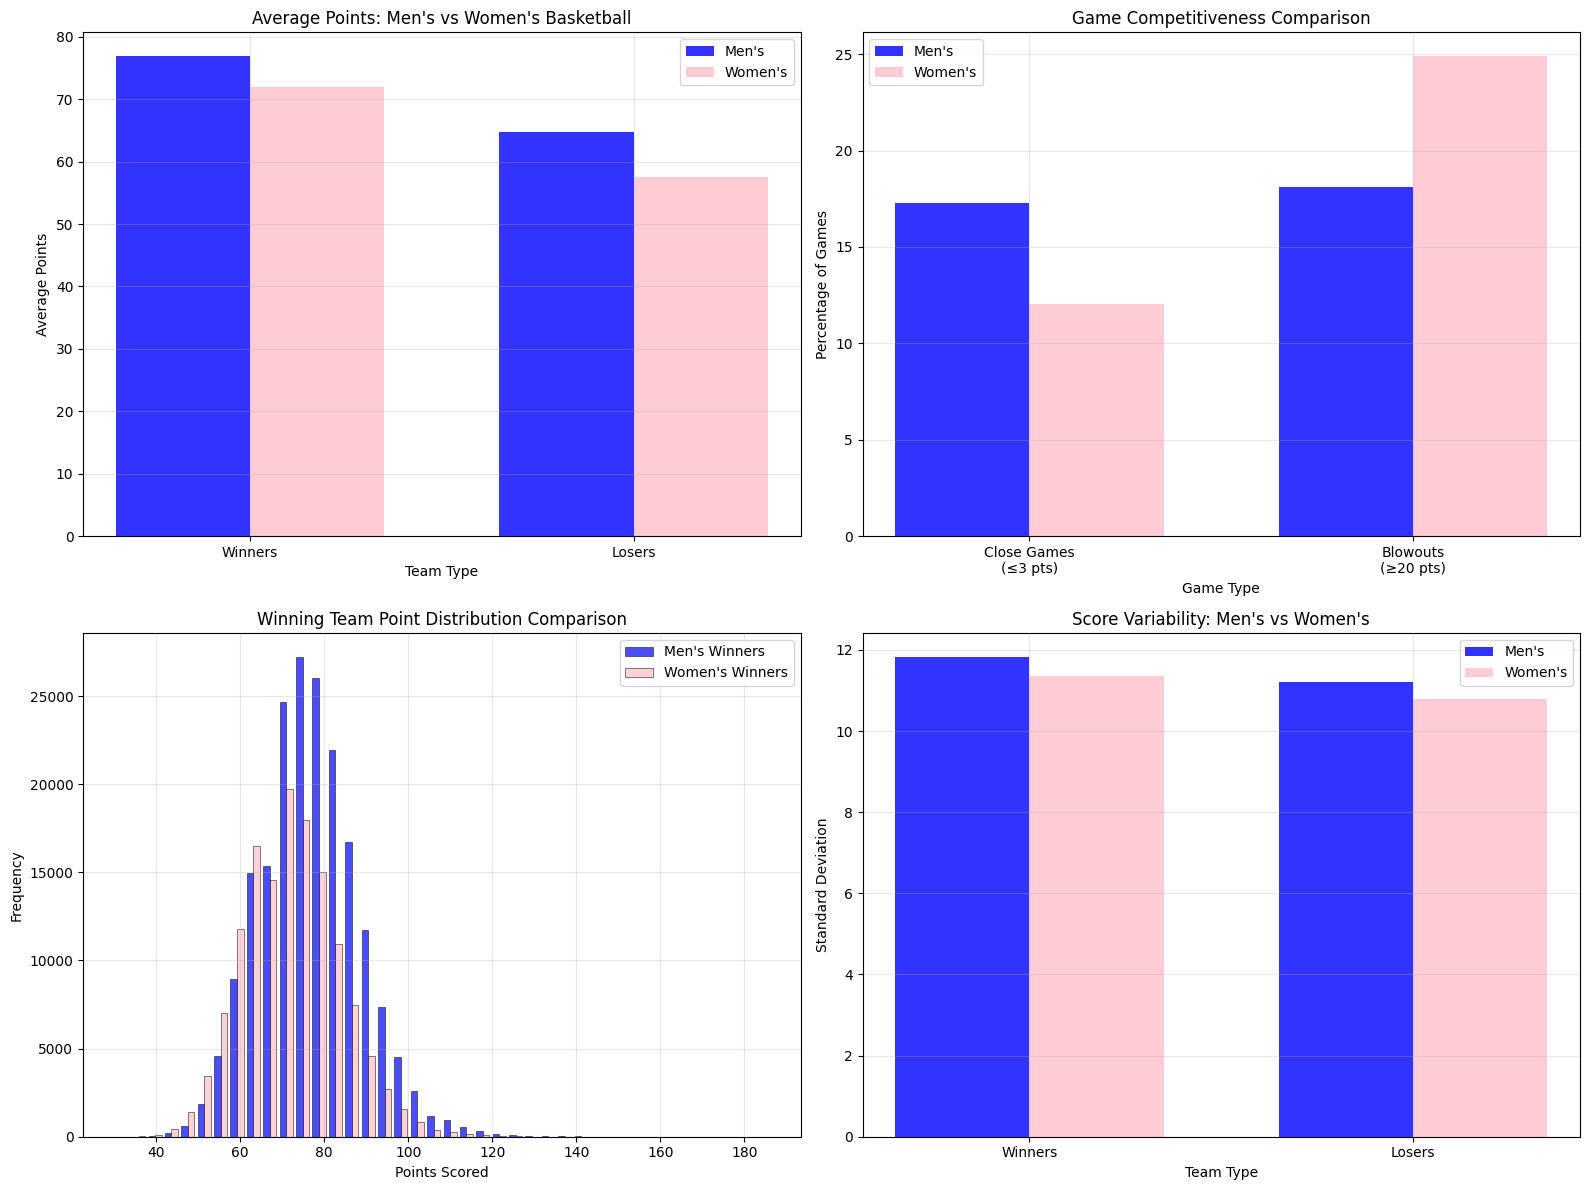

• Scoring Differences: Men's games average 4.9 more points per winning team
• Competitiveness: Men's games are 5.2% more likely to be close
• Score Variability: Men's winning scores show 0.5 more points of variability


In [129]:
print("Key Differences Summary:")
print(f"{'Metric':<25} {"Men's":<12} {"Women's":<12} {'Difference':<15}")
print("-" * 70)

metrics = [
    ("Avg Winner Score", "winning_mean", ".1f"),
    ("Avg Loser Score", "losing_mean", ".1f"),
    ("Avg Winning Margin", "avg_margin", ".1f"),
    ("Winner Std Dev", "winning_std", ".1f"),
    ("Loser Std Dev", "losing_std", ".1f"),
    ("Close Games %", "close_games_pct", ".1f"),
    ("Blowout Games %", "blowout_games_pct", ".1f"),
    ("High Scoring Winners %", "high_scoring_winners_pct", ".1f"),
    ("Low Scoring Winners %", "low_scoring_winners_pct", ".1f"),
]

for name, key, fmt in metrics:
    men_val = men_results[key]
    women_val = women_results[key]
    diff = men_val - women_val

    men_str = f"{men_val:{fmt}}"
    women_str = f"{women_val:{fmt}}"
    diff_str = f"+{diff:{fmt}}" if diff >= 0 else f"{diff:{fmt}}"

    print(f"{name:<25} {men_str:<12} {women_str:<12} {diff_str:<15}")

print(f"\nTotal Games: Men's = {men_results['total_games']:,}, Women's = {women_results['total_games']:,}")

# Side-by-side comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average scores comparison
categories = ["Winners", "Losers"]
men_avgs = [men_results["winning_mean"], men_results["losing_mean"]]
women_avgs = [women_results["winning_mean"], women_results["losing_mean"]]

x = np.arange(len(categories))
width = 0.35

axes[0, 0].bar(x - width / 2, men_avgs, width, label="Men's", alpha=0.8, color="blue")
axes[0, 0].bar(x + width / 2, women_avgs, width, label="Women's", alpha=0.8, color="pink")
axes[0, 0].set_xlabel("Team Type")
axes[0, 0].set_ylabel("Average Points")
axes[0, 0].set_title("Average Points: Men's vs Women's Basketball")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(categories)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Game competitiveness comparison
comp_categories = ["Close Games\n(≤3 pts)", "Blowouts\n(≥20 pts)"]
men_comp = [men_results["close_games_pct"], men_results["blowout_games_pct"]]
women_comp = [women_results["close_games_pct"], women_results["blowout_games_pct"]]

x = np.arange(len(comp_categories))
axes[0, 1].bar(x - width / 2, men_comp, width, label="Men's", alpha=0.8, color="blue")
axes[0, 1].bar(x + width / 2, women_comp, width, label="Women's", alpha=0.8, color="pink")
axes[0, 1].set_xlabel("Game Type")
axes[0, 1].set_ylabel("Percentage of Games")
axes[0, 1].set_title("Game Competitiveness Comparison")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comp_categories)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Combined point distribution comparison
axes[1, 0].hist(
    [men_regular["WScore"], women_regular["WScore"]],
    bins=40,
    alpha=0.7,
    label=["Men's Winners", "Women's Winners"],
    color=["blue", "pink"],
    edgecolor="black",
    linewidth=0.5,
)
axes[1, 0].set_title("Winning Team Point Distribution Comparison")
axes[1, 0].set_xlabel("Points Scored")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Standard deviation comparison
std_categories = ["Winners", "Losers"]
men_stds = [men_results["winning_std"], men_results["losing_std"]]
women_stds = [women_results["winning_std"], women_results["losing_std"]]

x = np.arange(len(std_categories))
axes[1, 1].bar(x - width / 2, men_stds, width, label="Men's", alpha=0.8, color="blue")
axes[1, 1].bar(x + width / 2, women_stds, width, label="Women's", alpha=0.8, color="pink")
axes[1, 1].set_xlabel("Team Type")
axes[1, 1].set_ylabel("Standard Deviation")
axes[1, 1].set_title("Score Variability: Men's vs Women's")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(std_categories)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("• Scoring Differences:", end="")
if men_results["winning_mean"] > women_results["winning_mean"]:
    print(
        f" Men's games average {men_results['winning_mean'] - women_results['winning_mean']:.1f} more points per winning team"
    )
else:
    print(
        f" Women's games average {women_results['winning_mean'] - men_results['winning_mean']:.1f} more points per winning team"
    )

print("• Competitiveness:", end="")
if men_results["close_games_pct"] > women_results["close_games_pct"]:
    print(
        f" Men's games are {men_results['close_games_pct'] - women_results['close_games_pct']:.1f}% more likely to be close"
    )
else:
    print(
        f" Women's games are {women_results['close_games_pct'] - men_results['close_games_pct']:.1f}% more likely to be close"
    )

print("• Score Variability:", end="")
if men_results["winning_std"] > women_results["winning_std"]:
    print(
        f" Men's winning scores show {men_results['winning_std'] - women_results['winning_std']:.1f} more points of variability"
    )
else:
    print(
        f" Women's winning scores show {women_results['winning_std'] - men_results['winning_std']:.1f} more points of variability"
    )

## 6. Tournament Seeding and Structure

In [133]:
men_seeds = pd.read_csv(data_dir / "MNCAATourneySeeds.csv")
women_seeds = pd.read_csv(data_dir / "WNCAATourneySeeds.csv")
men_slots = pd.read_csv(data_dir / "MNCAATourneySlots.csv")
women_slots = pd.read_csv(data_dir / "WNCAATourneySlots.csv")

In [135]:
print(f"Men's tournament seeds: {len(men_seeds):,} (seasons: {men_seeds['Season'].nunique()})")
print(f"Women's tournament seeds: {len(women_seeds):,} (seasons: {women_seeds['Season'].nunique()})")
print(f"Men's tournament slots: {len(men_slots):,}")
print(f"Women's tournament slots: {len(women_slots):,}")

Men's tournament seeds: 2,626 (seasons: 40)
Women's tournament seeds: 1,744 (seasons: 27)
Men's tournament slots: 2,586
Women's tournament slots: 1,780


In [137]:
men_seeds

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374
...,...,...,...
2621,2025,Z12,1161
2622,2025,Z13,1213
2623,2025,Z14,1423
2624,2025,Z15,1303


In [138]:
women_seeds

,Season,Seed,TeamID
0,1998,W01,3330
1,1998,W02,3163
2,1998,W03,3112
3,1998,W04,3301
4,1998,W05,3272
...,...,...,...
1739,2025,Z12,3193
1740,2025,Z13,3251
1741,2025,Z14,3195
1742,2025,Z15,3117


In [139]:
men_seeds["SeedNum"] = men_seeds["Seed"].str.extract("(\d+)").astype(int)
men_seeds["Region"] = men_seeds["Seed"].str.extract("([A-Z]+)")
men_seeds

,Season,Seed,TeamID,SeedNum,Region
0,1985,W01,1207,1,W
1,1985,W02,1210,2,W
2,1985,W03,1228,3,W
3,1985,W04,1260,4,W
4,1985,W05,1374,5,W
...,...,...,...,...,...
2621,2025,Z12,1161,12,Z
2622,2025,Z13,1213,13,Z
2623,2025,Z14,1423,14,Z
2624,2025,Z15,1303,15,Z


In [140]:
women_seeds["SeedNum"] = women_seeds["Seed"].str.extract("(\d+)").astype(int)
women_seeds["Region"] = women_seeds["Seed"].str.extract("([A-Z]+)")
women_seeds

,Season,Seed,TeamID,SeedNum,Region
0,1998,W01,3330,1,W
1,1998,W02,3163,2,W
2,1998,W03,3112,3,W
3,1998,W04,3301,4,W
4,1998,W05,3272,5,W
...,...,...,...,...,...
1739,2025,Z12,3193,12,Z
1740,2025,Z13,3251,13,Z
1741,2025,Z14,3195,14,Z
1742,2025,Z15,3117,15,Z



Seeding Distribution (Men's):


<Axes: xlabel='SeedNum'>

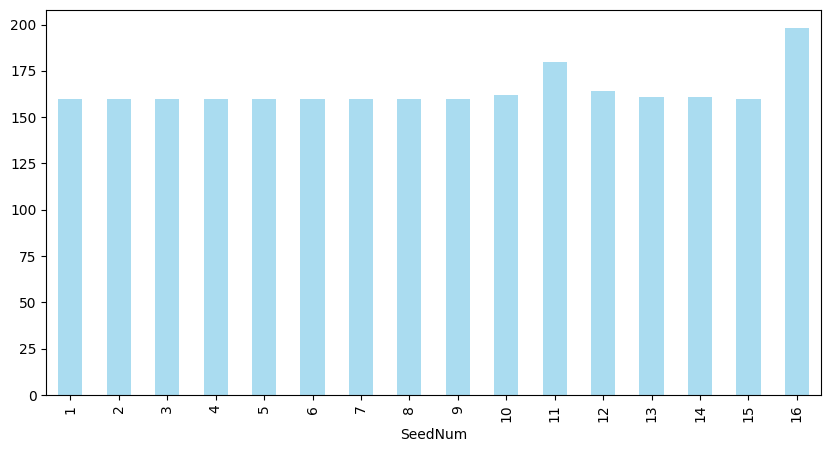

In [ ]:
seed_counts = men_seeds["SeedNum"].value_counts().sort_index()
seed_counts.plot(kind="bar", figsize=(10, 5), color="skyblue", alpha=0.7)

<Axes: xlabel='SeedNum'>

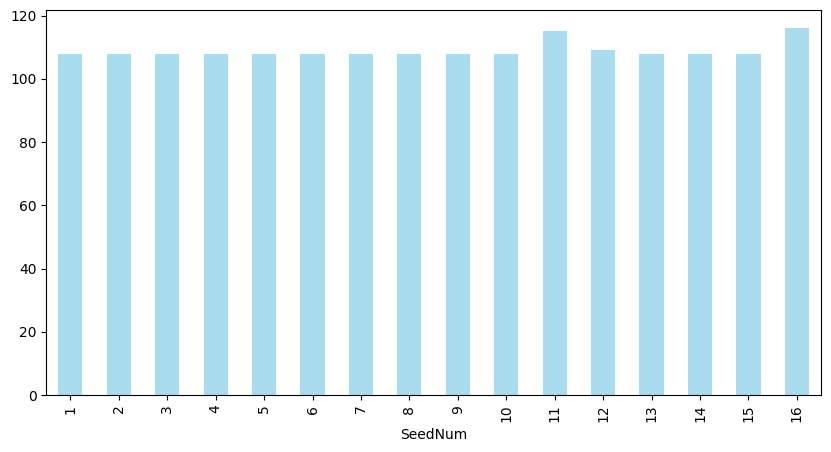

In [168]:
seed_counts = women_seeds["SeedNum"].value_counts().sort_index()
seed_counts.plot(kind="bar", figsize=(10, 5), color="skyblue", alpha=0.7)

There seems to be an odd irregularity with seed 11 & 16, but that might be specific to basketball?

In [169]:
print(f"\nRegion Distribution (Men's):")
region_counts = men_seeds["Region"].value_counts()
for region, count in region_counts.items():
    print(f"Region {region}: {count:3d} teams")


Region Distribution (Men's):
Region W: 659 teams
Region Y: 659 teams
Region X: 655 teams
Region Z: 653 teams


In [176]:
def analyze_seed_win_correlation(tourney_data, seeds_data, dataset_name="Dataset", show_plots=True):
    """
    Analyze the correlation between tournament seeds and winning performance.

    Parameters:
    tourney_data: DataFrame with tournament game results
    seeds_data: DataFrame with seeding information
    dataset_name: String identifier for the dataset (e.g., "Men's", "Women's")
    show_plots: Boolean to control visualization display

    Returns:
    Dictionary with seed performance analysis results
    """

    # Merge tournament results with seeds
    tourney_with_seeds = tourney_data.merge(
        seeds_data.rename(columns={"TeamID": "WTeamID", "Seed": "WSeed", "SeedNum": "WSeedNum"}),
        on=["Season", "WTeamID"],
        how="left",
    )
    tourney_with_seeds = tourney_with_seeds.merge(
        seeds_data.rename(columns={"TeamID": "LTeamID", "Seed": "LSeed", "SeedNum": "LSeedNum"}),
        on=["Season", "LTeamID"],
        how="left",
    )

    # Filter to games where both seeds are known
    games_with_seeds = tourney_with_seeds[
        tourney_with_seeds["WSeedNum"].notna() & tourney_with_seeds["LSeedNum"].notna()
    ]

    if len(games_with_seeds) == 0:
        print("No games found with complete seed information.")
        return {"dataset_name": dataset_name, "games_analyzed": 0}

    # Calculate upset statistics (lower seed beating higher seed)
    upsets = games_with_seeds[games_with_seeds["WSeedNum"] > games_with_seeds["LSeedNum"]]
    upset_rate = len(upsets) / len(games_with_seeds) * 100

    print(f"\nUPSET ANALYSIS:")
    print(f"Total upsets: {len(upsets):,} ({upset_rate:.1f}%)")
    print(f"Favored wins: {len(games_with_seeds) - len(upsets):,} ({100 - upset_rate:.1f}%)")

    # Biggest upsets by seed difference
    if len(upsets) > 0:
        upsets = upsets.copy()
        upsets["SeedDiff"] = upsets["WSeedNum"] - upsets["LSeedNum"]
        biggest_upsets = upsets.nlargest(5, "SeedDiff")[["Season", "WSeedNum", "LSeedNum", "SeedDiff"]]
        print(f"\nTop 5 Biggest Upsets:")
        for _, upset in biggest_upsets.iterrows():
            print(
                f"  {upset['Season']}: #{int(upset['WSeedNum'])} beat #{int(upset['LSeedNum'])} (diff: +{int(upset['SeedDiff'])})"
            )

    # Seed win rate analysis
    seed_performance = []
    for seed in range(1, 17):  # Standard 1-16 seeds
        seed_games = games_with_seeds[(games_with_seeds["WSeedNum"] == seed) | (games_with_seeds["LSeedNum"] == seed)]
        wins = len(seed_games[seed_games["WSeedNum"] == seed])
        total_games = len(seed_games)
        win_rate = wins / total_games * 100 if total_games > 0 else 0

        seed_performance.append({"Seed": seed, "Wins": wins, "Games": total_games, "WinRate": win_rate})

    seed_perf_df = pd.DataFrame(seed_performance)

    valid_seeds = seed_perf_df[seed_perf_df["Games"] > 0]
    if len(valid_seeds) > 1:
        from scipy.stats import pearsonr

        correlation, p_value = pearsonr(valid_seeds["Seed"], valid_seeds["WinRate"])
        print(f"\nSEED-PERFORMANCE CORRELATION:")
        print(f"Correlation coefficient: {correlation:.4f}")
        print(f"P-value: {p_value:.6f}")
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not significant"
        print(f"Statistical significance: {significance}")

    # Results dictionary
    results = {
        "dataset_name": dataset_name,
        "games_analyzed": len(games_with_seeds),
        "upset_rate": upset_rate,
        "seed_performance": seed_perf_df.to_dict("records"),
        "correlation": correlation if len(valid_seeds) > 1 else None,
        "correlation_p_value": p_value if len(valid_seeds) > 1 else None,
    }

    # Visualization
    if show_plots and len(valid_seeds) > 0:
        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Seed win rates
        axes[0].plot(
            valid_seeds["Seed"], valid_seeds["WinRate"], marker="o", linewidth=2, markersize=6, color="darkblue"
        )
        axes[0].set_title(f"{dataset_name} Tournament Win Rate by Seed")
        axes[0].set_xlabel("Seed Number (1=best, 16=worst)")
        axes[0].set_ylabel("Win Rate (%)")
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xticks(range(1, 17))

        # Add trend line if correlation exists
        if correlation is not None:
            z = np.polyfit(valid_seeds["Seed"], valid_seeds["WinRate"], 1)
            p = np.poly1d(z)
            axes[0].plot(
                valid_seeds["Seed"], p(valid_seeds["Seed"]), "r--", alpha=0.8, label=f"Trend (r={correlation:.3f})"
            )
            axes[0].legend()

        # Upset analysis
        categories = ["Favored Wins", "Upsets"]
        values = [100 - upset_rate, upset_rate]
        colors = ["lightgreen", "lightcoral"]

        wedges, texts, autotexts = axes[1].pie(
            values, labels=categories, autopct="%1.1f%%", colors=colors, startangle=90
        )
        axes[1].set_title(f"{dataset_name} Tournament Upset Rate")

        plt.tight_layout()
        plt.show()

    return results


UPSET ANALYSIS:
Total upsets: 695 (27.6%)
Favored wins: 1,823 (72.4%)

Top 5 Biggest Upsets:
  2018: #16 beat #1 (diff: +15)
  2023: #16 beat #1 (diff: +15)
  1991: #15 beat #2 (diff: +13)
  1993: #15 beat #2 (diff: +13)
  1997: #15 beat #2 (diff: +13)

SEED-PERFORMANCE CORRELATION:
Correlation coefficient: -0.9663
P-value: 0.000000
Statistical significance: SIGNIFICANT


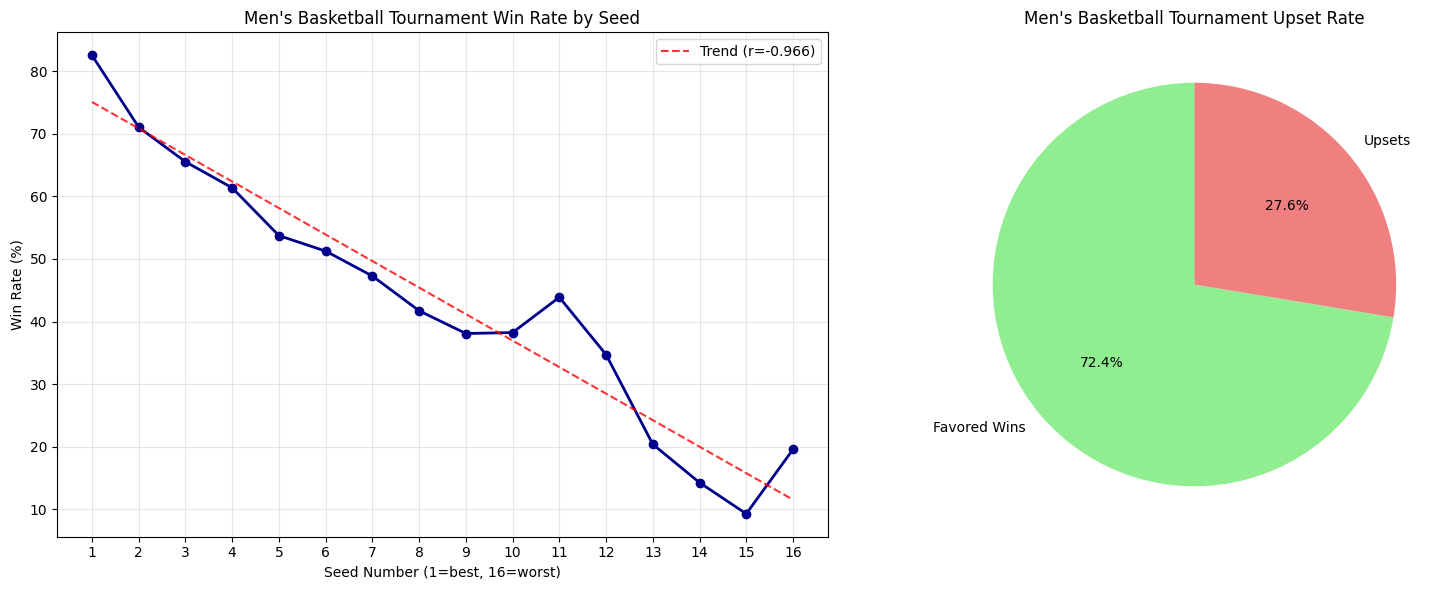

In [177]:
men_seed_results = analyze_seed_win_correlation(men_tourney, men_seeds, "Men's Basketball")


UPSET ANALYSIS:
Total upsets: 352 (21.3%)
Favored wins: 1,298 (78.7%)

Top 5 Biggest Upsets:
  1998: #16 beat #1 (diff: +15)
  2000: #13 beat #4 (diff: +9)
  2004: #13 beat #4 (diff: +9)
  2005: #13 beat #4 (diff: +9)
  2007: #13 beat #4 (diff: +9)

SEED-PERFORMANCE CORRELATION:
Correlation coefficient: -0.9820
P-value: 0.000000
Statistical significance: SIGNIFICANT


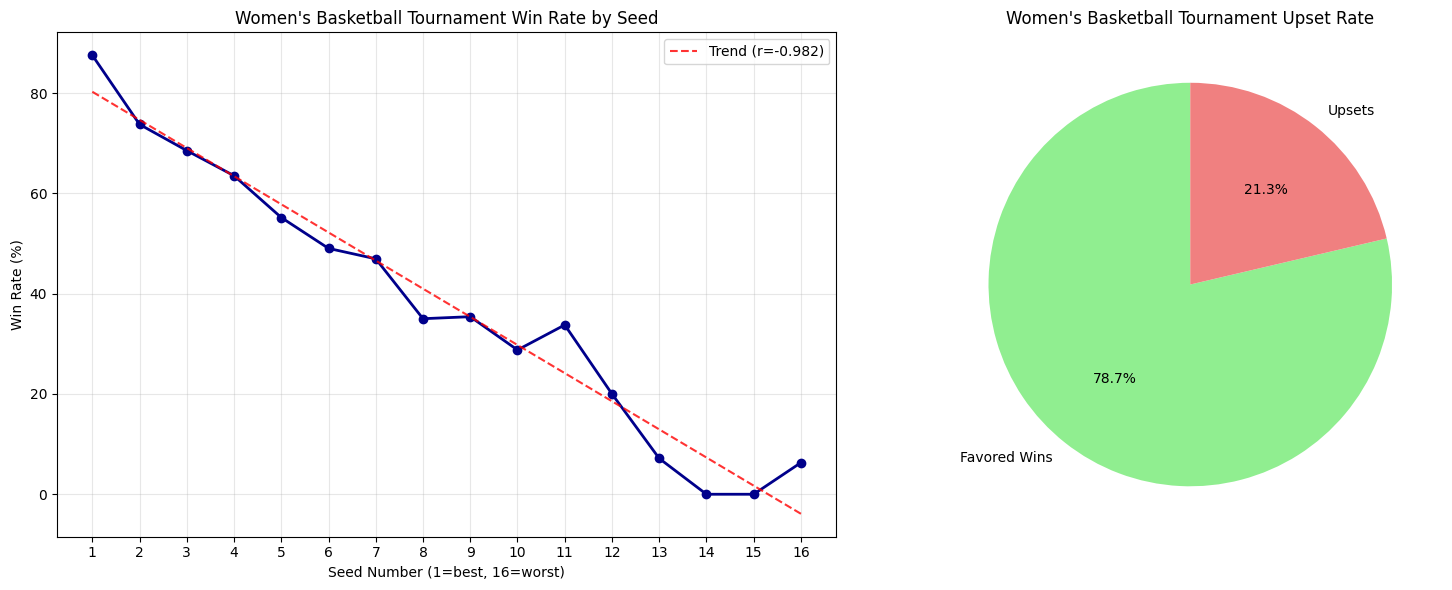

In [178]:
women_seed_results = analyze_seed_win_correlation(women_tourney, women_seeds, "Women's Basketball")

Again seeds 11 and 16 seem somewhat irregular in regard to their win rate.

## 7. Detailed Game Statistics Analysis

In [203]:
def analyze_detailed_game_statistics(file_path, dataset_name="Dataset", game_type="Regular Season", show_plots=True):
    """
    Analyze detailed game statistics and their correlation with winning.

    Parameters:
    file_path: Path to the detailed results CSV file
    dataset_name: String identifier (e.g., "Men's", "Women's")
    game_type: Type of games ("Regular Season", "Tournament")
    show_plots: Boolean to control visualization display

    Returns:
    Dictionary with detailed statistics analysis results
    """

    try:
        detailed_data = pd.read_csv(file_path)

        if len(detailed_data) == 0:
            return {"dataset_name": dataset_name, "game_type": game_type, "games_analyzed": 0}

        detailed_stats = detailed_data.copy()

        # Calculate statistics with zero-division protection
        detailed_stats["WFGP"] = np.where(
            detailed_stats["WFGA"] > 0, detailed_stats["WFGM"] / detailed_stats["WFGA"], 0
        )
        detailed_stats["LFGP"] = np.where(
            detailed_stats["LFGA"] > 0, detailed_stats["LFGM"] / detailed_stats["LFGA"], 0
        )
        detailed_stats["W3PP"] = np.where(
            detailed_stats["WFGA3"] > 0, detailed_stats["WFGM3"] / detailed_stats["WFGA3"], 0
        )
        detailed_stats["L3PP"] = np.where(
            detailed_stats["LFGA3"] > 0, detailed_stats["LFGM3"] / detailed_stats["LFGA3"], 0
        )
        detailed_stats["WFTP"] = np.where(
            detailed_stats["WFTA"] > 0, detailed_stats["WFTM"] / detailed_stats["WFTA"], 0
        )
        detailed_stats["LFTP"] = np.where(
            detailed_stats["LFTA"] > 0, detailed_stats["LFTM"] / detailed_stats["LFTA"], 0
        )
        detailed_stats["WTotalReb"] = detailed_stats["WOR"] + detailed_stats["WDR"]
        detailed_stats["LTotalReb"] = detailed_stats["LOR"] + detailed_stats["LDR"]

        # Calculate margins for correlation analysis
        detailed_stats["ScoreMargin"] = detailed_stats["WScore"] - detailed_stats["LScore"]
        detailed_stats["FGMargin"] = detailed_stats["WFGP"] - detailed_stats["LFGP"]
        detailed_stats["ThreePointMargin"] = detailed_stats["W3PP"] - detailed_stats["L3PP"]
        detailed_stats["FTMargin"] = detailed_stats["WFTP"] - detailed_stats["LFTP"]
        detailed_stats["ReboundMargin"] = detailed_stats["WTotalReb"] - detailed_stats["LTotalReb"]
        detailed_stats["TurnoverMargin"] = detailed_stats["LTO"] - detailed_stats["WTO"]  # Lower TO is better
        detailed_stats["StealMargin"] = detailed_stats["WStl"] - detailed_stats["LStl"]
        detailed_stats["AssistMargin"] = detailed_stats["WAst"] - detailed_stats["LAst"]
        detailed_stats["BlockMargin"] = detailed_stats["WBlk"] - detailed_stats["LBlk"]

        # Calculate correlations with victory margin
        margin_stats = [
            "FGMargin",
            "ThreePointMargin",
            "FTMargin",
            "ReboundMargin",
            "TurnoverMargin",
            "StealMargin",
            "AssistMargin",
            "BlockMargin",
        ]

        correlations = {}
        for stat in margin_stats:
            if detailed_stats[stat].std() > 0:
                correlations[stat] = detailed_stats["ScoreMargin"].corr(detailed_stats[stat])

        # Store results
        results = {
            "dataset_name": dataset_name,
            "game_type": game_type,
            "games_analyzed": len(detailed_data),
            "correlations": correlations,
            "data": detailed_stats,
        }

        # Visualization
        if show_plots:
            import matplotlib.pyplot as plt

            # Create two separate figures: one for distributions, one for correlations

            # Figure 1: Statistical distributions (Winners vs Losers)
            fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10))
            fig1.suptitle(f"{dataset_name} {game_type}: Statistical Distributions", fontsize=16, fontweight="bold")

            stats_to_plot = [
                ("WFGP", "LFGP", "Field Goal %"),
                ("W3PP", "L3PP", "3-Point %"),
                ("WFTP", "LFTP", "Free Throw %"),
                ("WTotalReb", "LTotalReb", "Total Rebounds"),
                ("WTO", "LTO", "Turnovers"),
                ("WStl", "LStl", "Steals"),
                ("WAst", "LAst", "Assists"),
                ("WBlk", "LBlk", "Blocks"),
            ]

            for i, (winner_col, loser_col, title) in enumerate(stats_to_plot):
                row, col = i // 4, i % 4
                axes1[row, col].hist(
                    [detailed_stats[winner_col].dropna(), detailed_stats[loser_col].dropna()],
                    bins=20,
                    alpha=0.7,
                    label=["Winners", "Losers"],
                    color=["darkgreen", "darkred"],
                )
                axes1[row, col].set_title(title)
                axes1[row, col].legend()
                axes1[row, col].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Figure 2: Correlation with victory margin
            fig2, ax2 = plt.subplots(1, 1, figsize=(12, 8))

            corr_values = list(correlations.values())
            stat_names = [
                stat.replace("Margin", "")
                .replace("FG", "Field Goal")
                .replace("ThreePoint", "3-Point")
                .replace("FT", "Free Throw")
                .replace("Turnover", "Turnover (-)")
                for stat in correlations.keys()
            ]

            colors = ["green" if x > 0 else "red" for x in corr_values]
            bars = ax2.bar(range(len(corr_values)), corr_values, color=colors, alpha=0.7)

            ax2.set_title(
                f"{dataset_name} {game_type}: Correlation with Victory Margin", fontsize=14, fontweight="bold"
            )
            ax2.set_ylabel("Correlation Coefficient")
            ax2.set_xlabel("Statistics")
            ax2.set_xticks(range(len(stat_names)))
            ax2.set_xticklabels(stat_names, rotation=45, ha="right")
            ax2.grid(True, alpha=0.3)
            ax2.axhline(y=0, color="black", linestyle="-", alpha=0.5)

            # Add value labels on bars
            for bar, value in zip(bars, corr_values):
                height = bar.get_height()
                ax2.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    height + (0.01 if height >= 0 else -0.03),
                    f"{value:.3f}",
                    ha="center",
                    va="bottom" if height >= 0 else "top",
                    fontweight="bold",
                )

            plt.tight_layout()
            plt.show()

        return results

    except FileNotFoundError:
        return {"dataset_name": dataset_name, "game_type": game_type, "games_analyzed": 0, "error": "File not found"}
    except Exception as e:
        return {"dataset_name": dataset_name, "game_type": game_type, "games_analyzed": 0, "error": str(e)}

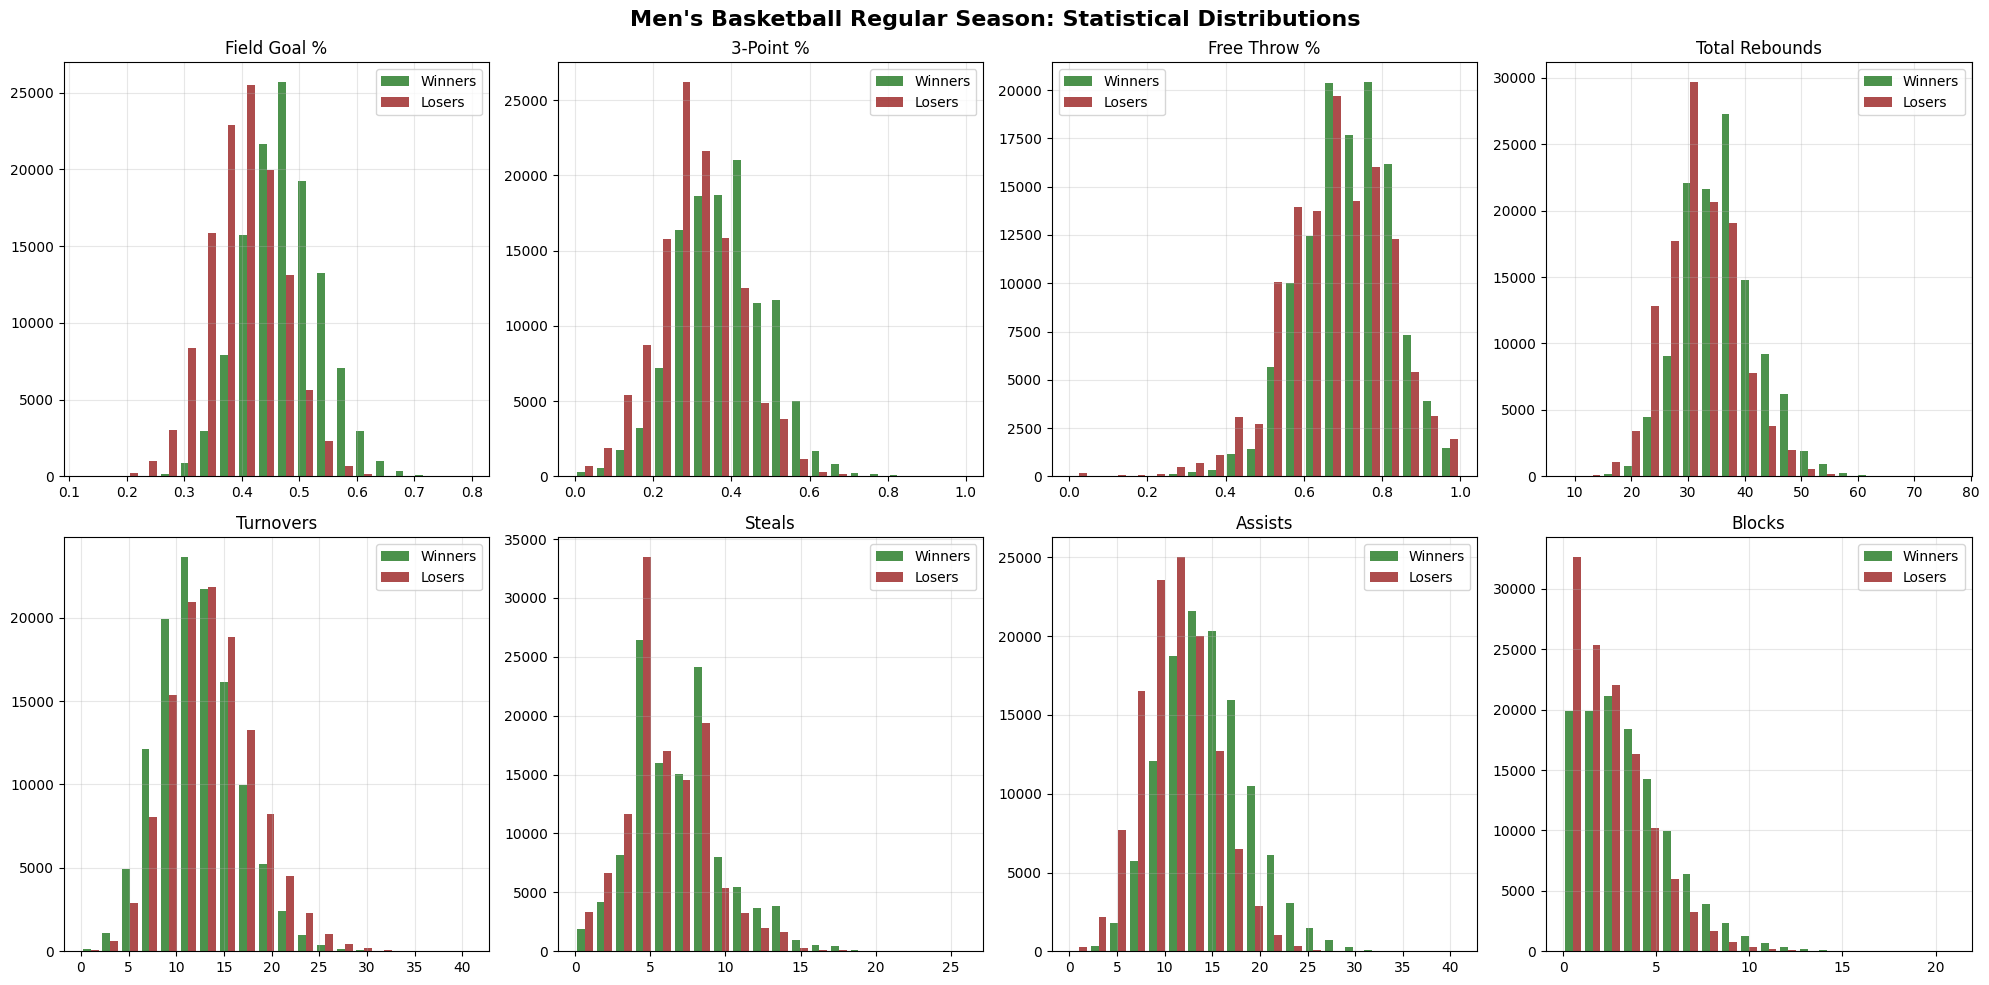

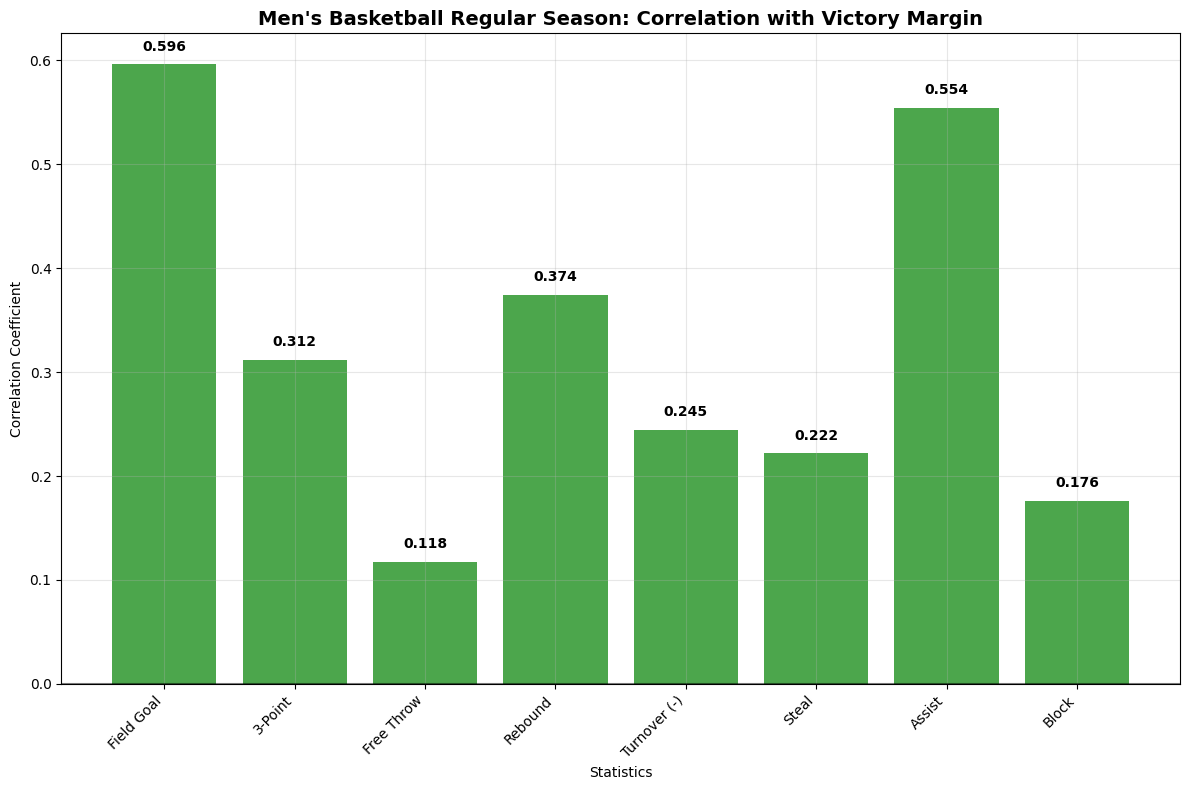

In [212]:
analyze_detailed_game_statistics("../data/MRegularSeasonDetailedResults.csv", "Men's Basketball", "Regular Season");

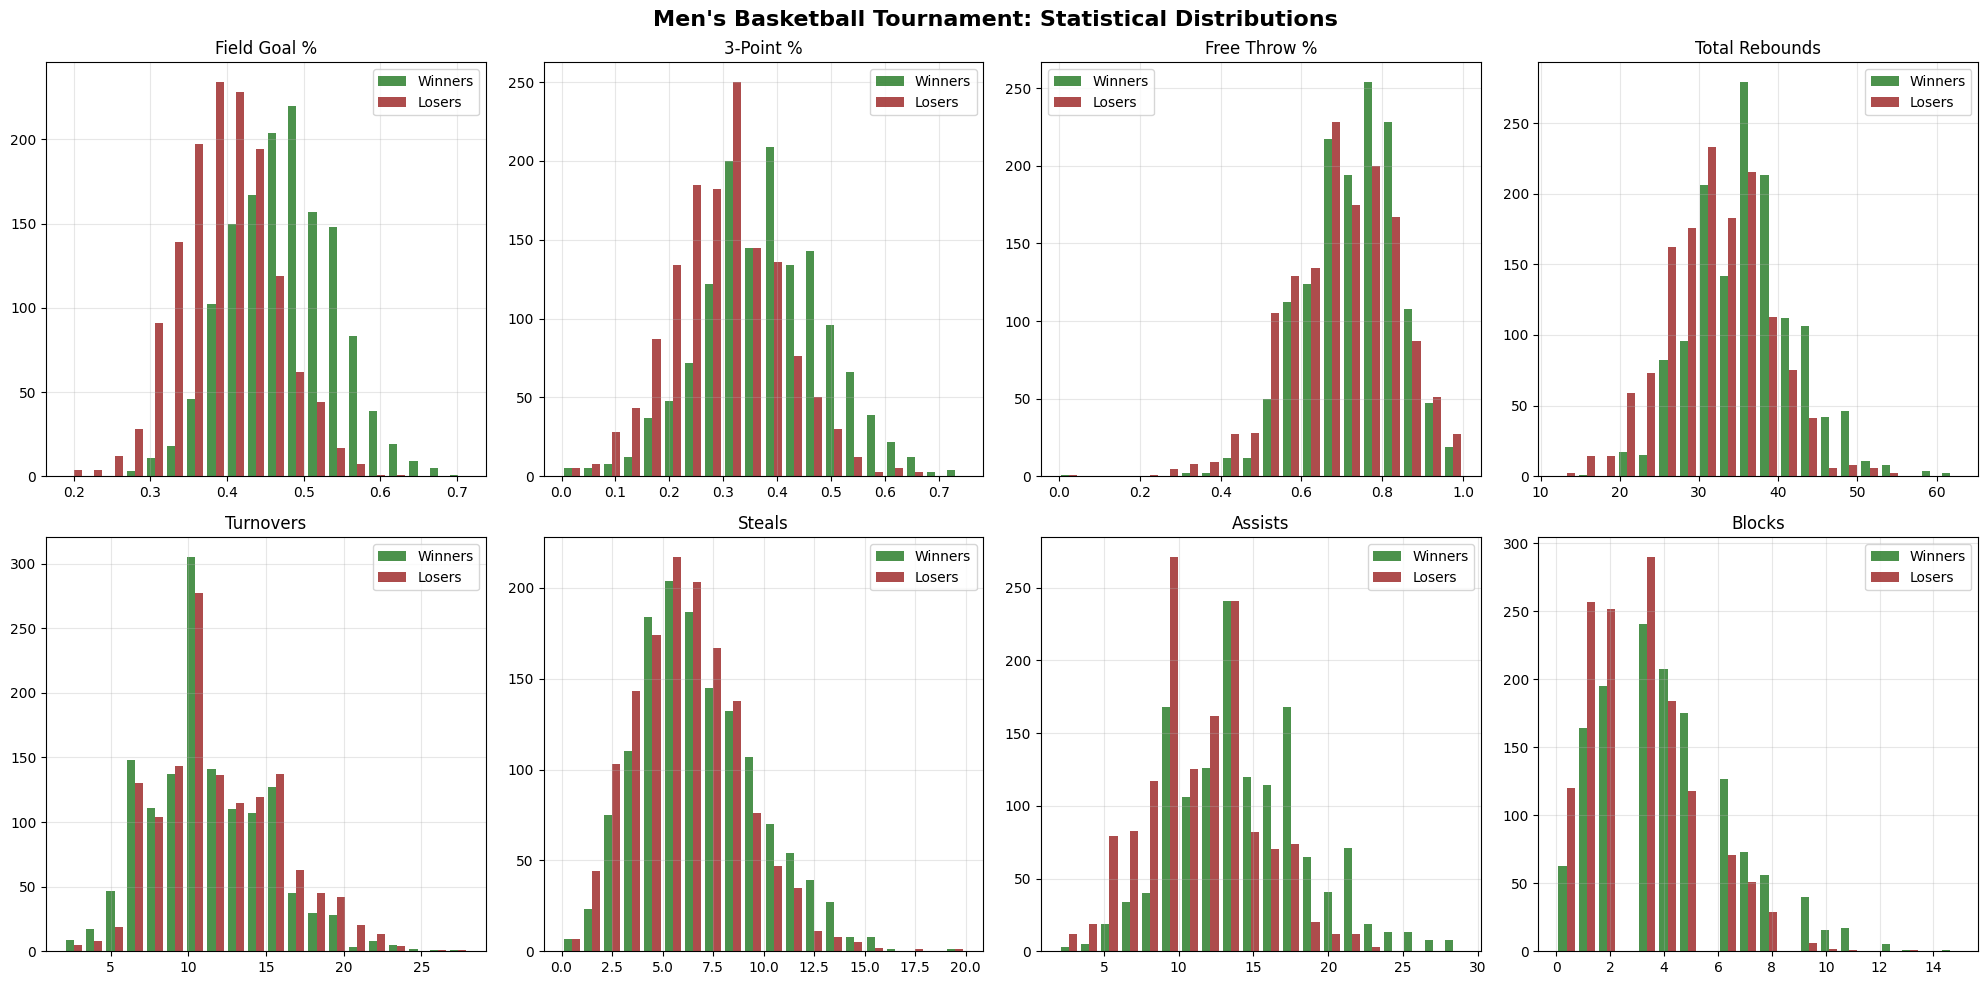

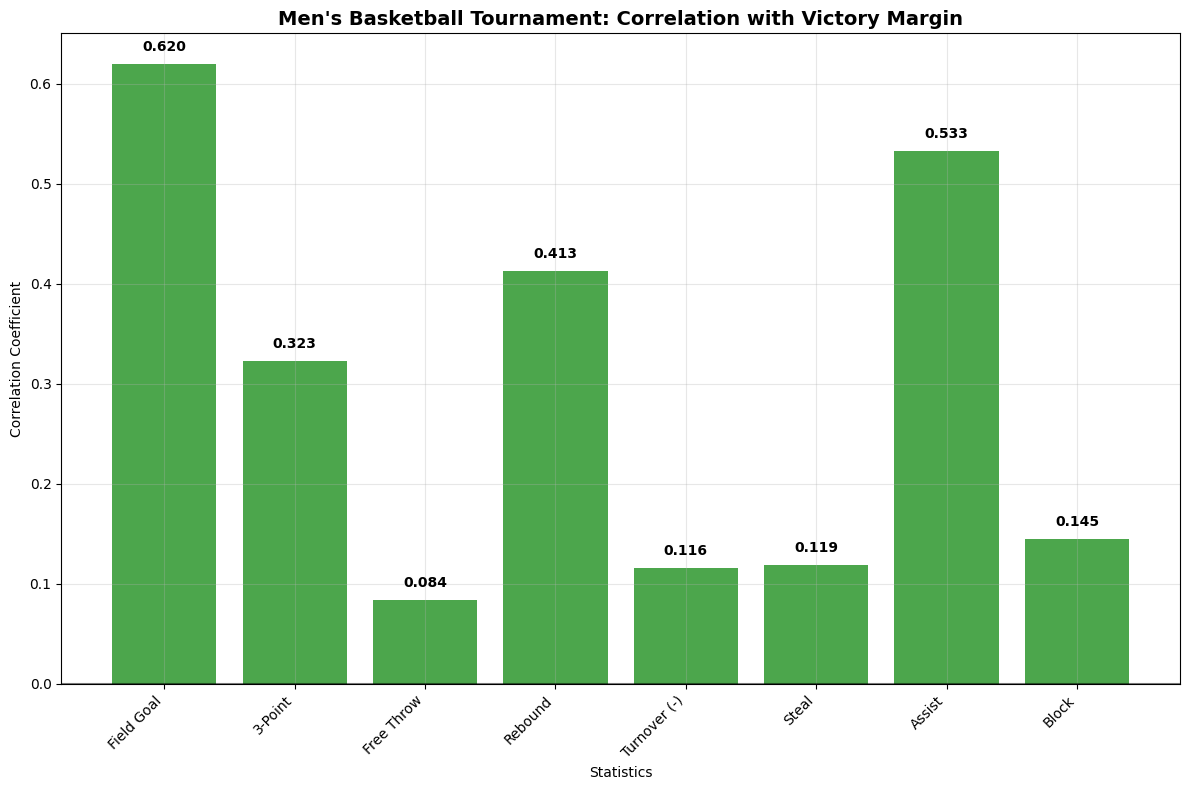

In [213]:
analyze_detailed_game_statistics("../data/MNCAATourneyDetailedResults.csv", "Men's Basketball", "Tournament");

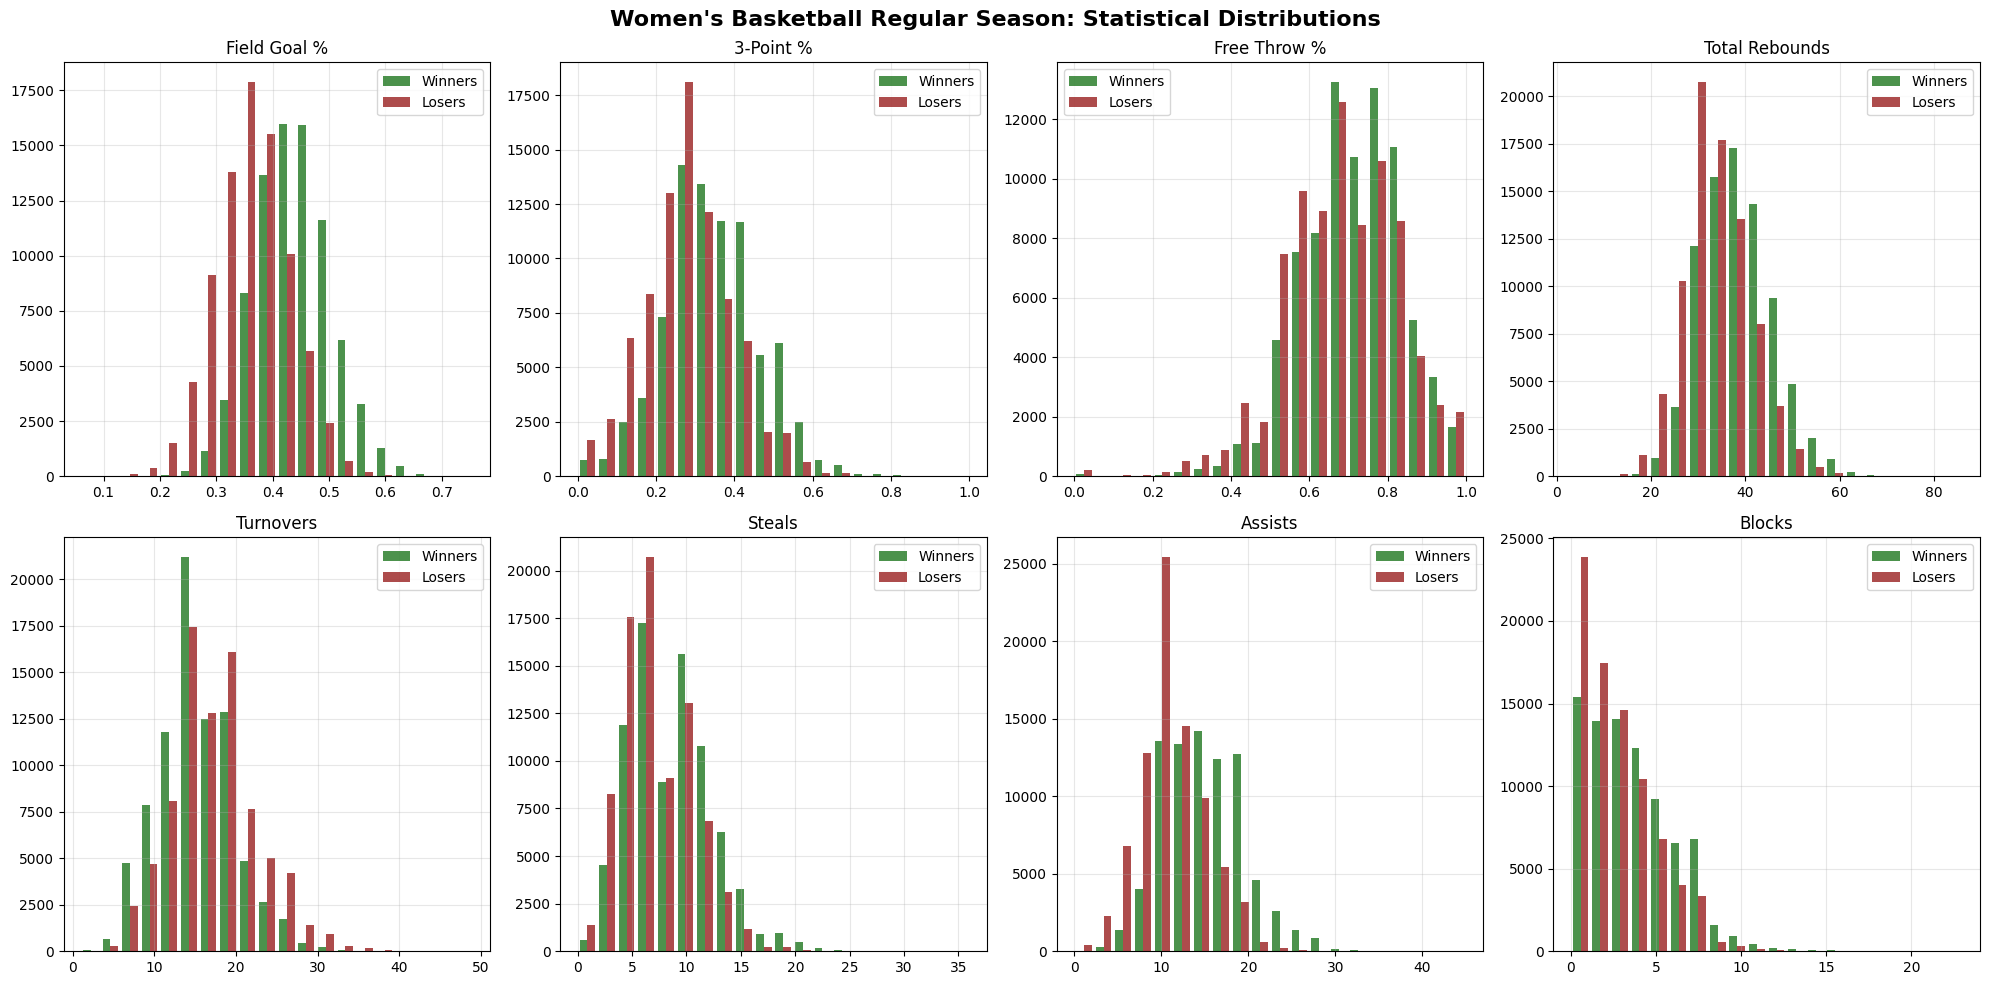

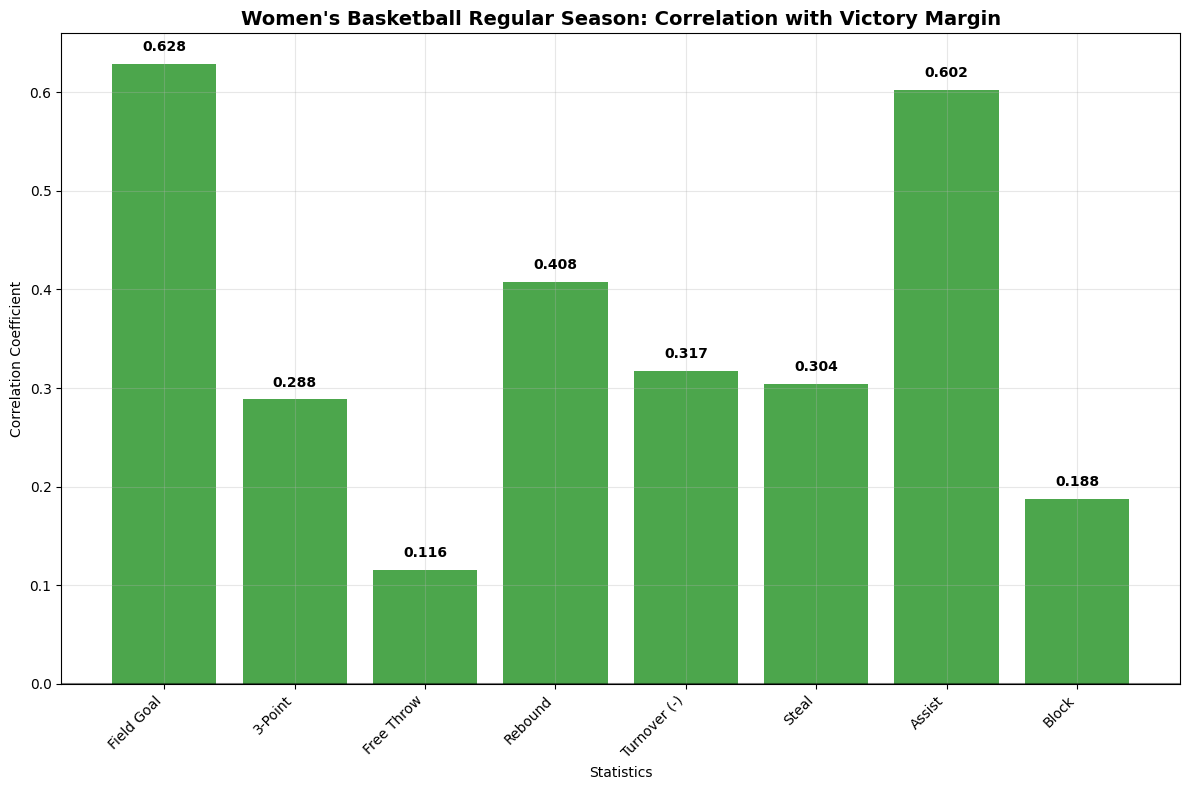

In [214]:
analyze_detailed_game_statistics("../data/WRegularSeasonDetailedResults.csv", "Women's Basketball", "Regular Season");

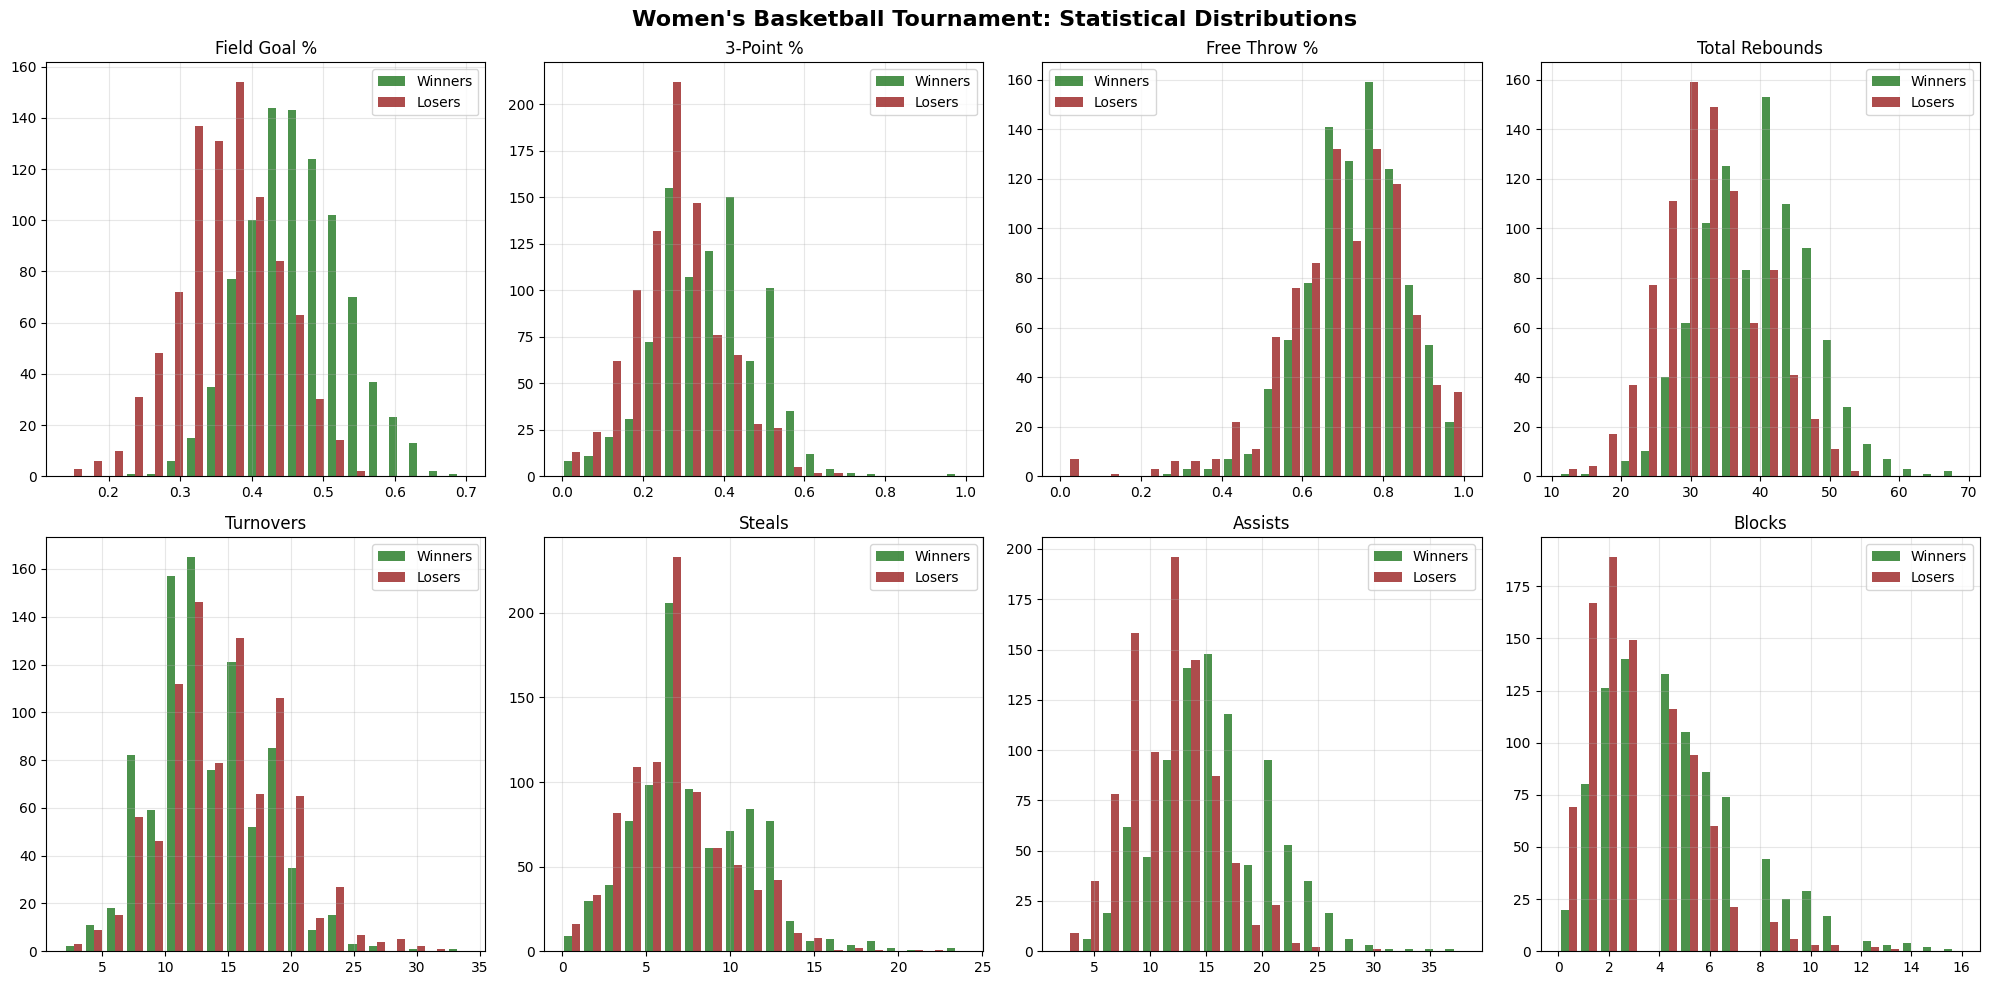

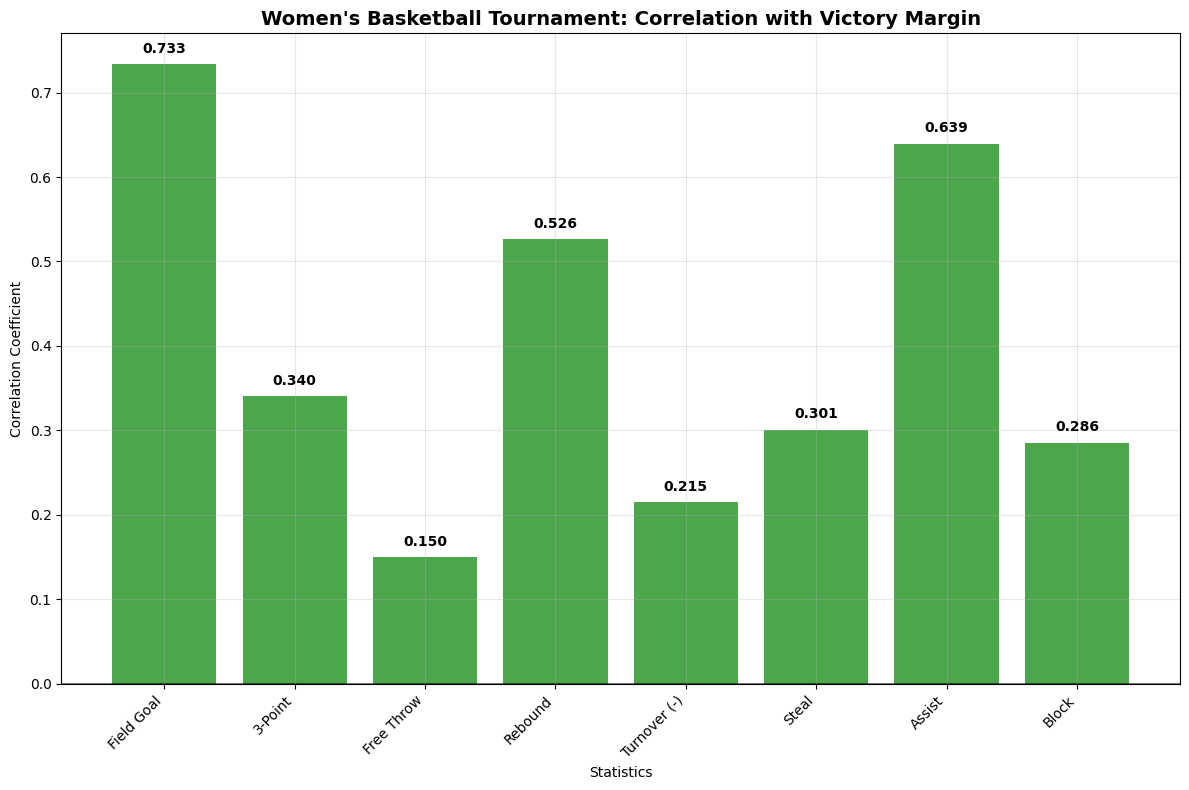

In [215]:
analyze_detailed_game_statistics("../data/WNCAATourneyDetailedResults.csv", "Women's Basketball", "Tournament");

## 8. Regional Patterns

In [163]:
def analyze_regional_game_patterns(game_data, dataset_name="Dataset", show_plots=True):
    """
    Analyze game patterns by geographic region using city/location data.

    Parameters:
    game_data: DataFrame with game results
    dataset_name: String identifier for the dataset (e.g., "Men's", "Women's")
    show_plots: Boolean to control visualization display

    Returns:
    Dictionary with regional analysis results
    """

    print(f"=" * 50)
    print(f"REGIONAL GAME ANALYSIS: {dataset_name.upper()}")
    print(f"=" * 50)

    # Load city data
    try:
        cities = pd.read_csv(data_dir / "Cities.csv")
        game_cities_file = f"{'M' if 'Men' in dataset_name else 'W'}GameCities.csv"
        game_cities = pd.read_csv(data_dir / game_cities_file)

        # Merge game data with city information
        games_with_cities = game_data.merge(
            game_cities, on=["Season", "DayNum", "WTeamID", "LTeamID"], how="left"
        ).merge(cities, on="CityID", how="left")

        print(
            f"Games with city data: {len(games_with_cities[games_with_cities['CityID'].notna()]):,} / {len(game_data):,}"
        )

        # Regional analysis
        if "CityID" in games_with_cities.columns and games_with_cities["CityID"].notna().sum() > 0:
            # Group cities by state for regional patterns
            regional_games = games_with_cities[games_with_cities["CityID"].notna()].copy()

            # Analyze by state
            state_counts = regional_games["State"].value_counts().head(10)

            print(f"\nTOP 10 STATES BY GAME COUNT:")
            for state, count in state_counts.items():
                pct = count / len(regional_games) * 100
                print(f"{state}: {count:,} games ({pct:.1f}%)")

            # Calculate scoring patterns by region
            regional_stats = (
                regional_games.groupby("State").agg({"WScore": "mean", "LScore": "mean", "Season": "count"}).round(1)
            )
            regional_stats.columns = ["Avg_Winner_Score", "Avg_Loser_Score", "Game_Count"]
            regional_stats["Avg_Total_Points"] = regional_stats["Avg_Winner_Score"] + regional_stats["Avg_Loser_Score"]
            regional_stats["Avg_Margin"] = regional_stats["Avg_Winner_Score"] - regional_stats["Avg_Loser_Score"]

            # Filter states with significant game counts (>= 50 games)
            significant_states = regional_stats[regional_stats["Game_Count"] >= 50].sort_values(
                "Game_Count", ascending=False
            )

            print(f"\nREGIONAL SCORING PATTERNS (States with ≥50 games):")
            print(f"{'State':<15} {'Games':<8} {'Avg Total':<12} {'Avg Margin':<12}")
            print("-" * 50)
            for state, row in significant_states.head(8).iterrows():
                print(
                    f"{state:<15} {row['Game_Count']:<8.0f} {row['Avg_Total_Points']:<12.1f} {row['Avg_Margin']:<12.1f}"
                )

            results = {
                "dataset_name": dataset_name,
                "total_games": len(game_data),
                "games_with_location": len(regional_games),
                "top_states": state_counts.to_dict(),
                "regional_stats": significant_states.to_dict("index"),
            }

            if show_plots and len(significant_states) > 0:
                import matplotlib.pyplot as plt

                fig, axes = plt.subplots(1, 2, figsize=(16, 6))

                # Plot 1: Games by state (top 8)
                top_8_states = state_counts.head(8)
                bars = axes[0].bar(range(len(top_8_states)), top_8_states.values, color="skyblue", alpha=0.8)
                axes[0].set_xlabel("State")
                axes[0].set_ylabel("Number of Games")
                axes[0].set_title(f"{dataset_name} Games by State (Top 8)")
                axes[0].set_xticks(range(len(top_8_states)))
                axes[0].set_xticklabels(top_8_states.index, rotation=45)
                axes[0].grid(True, alpha=0.3)

                # Add value labels
                for bar, value in zip(bars, top_8_states.values):
                    axes[0].text(
                        bar.get_x() + bar.get_width() / 2.0,
                        bar.get_height() + 50,
                        f"{value:,}",
                        ha="center",
                        va="bottom",
                        fontsize=10,
                    )

                # Plot 2: Scoring patterns by region
                plot_states = significant_states.head(8)
                x = range(len(plot_states))
                axes[1].scatter(
                    x,
                    plot_states["Avg_Total_Points"],
                    s=plot_states["Game_Count"] / 10,
                    alpha=0.6,
                    color="orange",
                    label="Avg Total Points",
                )
                axes[1].set_xlabel("State (ordered by game count)")
                axes[1].set_ylabel("Average Total Points per Game")
                axes[1].set_title(f"{dataset_name} Scoring Patterns by Region\n(Bubble size = game count)")
                axes[1].set_xticks(x)
                axes[1].set_xticklabels(plot_states.index, rotation=45)
                axes[1].grid(True, alpha=0.3)

                plt.tight_layout()
                plt.show()

            return results

        else:
            print("No city/regional data available for analysis")
            return {"dataset_name": dataset_name, "games_with_location": 0}

    except FileNotFoundError as e:
        print(f"Regional data files not found: {e}")
        return {"dataset_name": dataset_name, "error": "Missing regional data files"}

REGIONAL GAME ANALYSIS: MEN'S BASKETBALL
Games with city data: 84,808 / 192,930

TOP 10 STATES BY GAME COUNT:
CA: 5,768 games (6.8%)
NY: 5,409 games (6.4%)
TX: 5,348 games (6.3%)
NC: 4,226 games (5.0%)
FL: 3,435 games (4.1%)
PA: 3,294 games (3.9%)
OH: 3,270 games (3.9%)
VA: 3,244 games (3.8%)
IL: 2,978 games (3.5%)
TN: 2,877 games (3.4%)

REGIONAL SCORING PATTERNS (States with ≥50 games):
State           Games    Avg Total    Avg Margin  
--------------------------------------------------
CA              5768     139.5        11.7        
NY              5409     140.3        11.1        
TX              5348     139.7        12.3        
NC              4226     142.2        11.8        
FL              3435     139.9        11.5        
PA              3294     140.4        11.6        
OH              3270     141.4        12.6        
VA              3244     138.3        12.1        


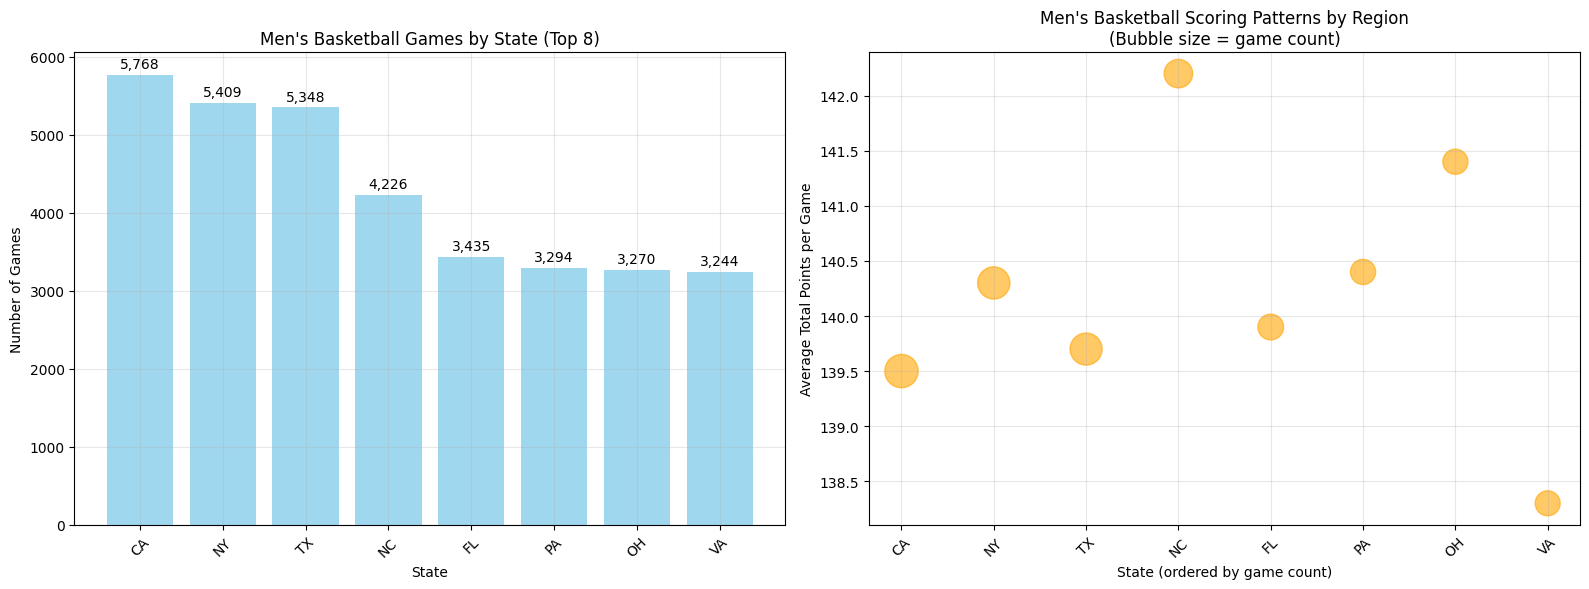

In [164]:
men_regional_results = analyze_regional_game_patterns(men_regular, "Men's Basketball")

REGIONAL GAME ANALYSIS: WOMEN'S BASKETBALL
Games with city data: 81,689 / 137,028

TOP 10 STATES BY GAME COUNT:
CA: 5,618 games (6.9%)
TX: 5,256 games (6.4%)
NY: 4,816 games (5.9%)
NC: 4,225 games (5.2%)
FL: 3,498 games (4.3%)
PA: 3,151 games (3.9%)
VA: 3,043 games (3.7%)
IL: 2,990 games (3.7%)
OH: 2,983 games (3.7%)
TN: 2,706 games (3.3%)

REGIONAL SCORING PATTERNS (States with ≥50 games):
State           Games    Avg Total    Avg Margin  
--------------------------------------------------
CA              5618     131.4        13.2        
TX              5256     129.5        15.1        
NY              4816     123.0        13.4        
NC              4225     127.1        14.3        
FL              3498     129.6        15.4        
PA              3151     125.7        13.9        
VA              3043     125.2        14.6        
IL              2990     133.5        14.3        


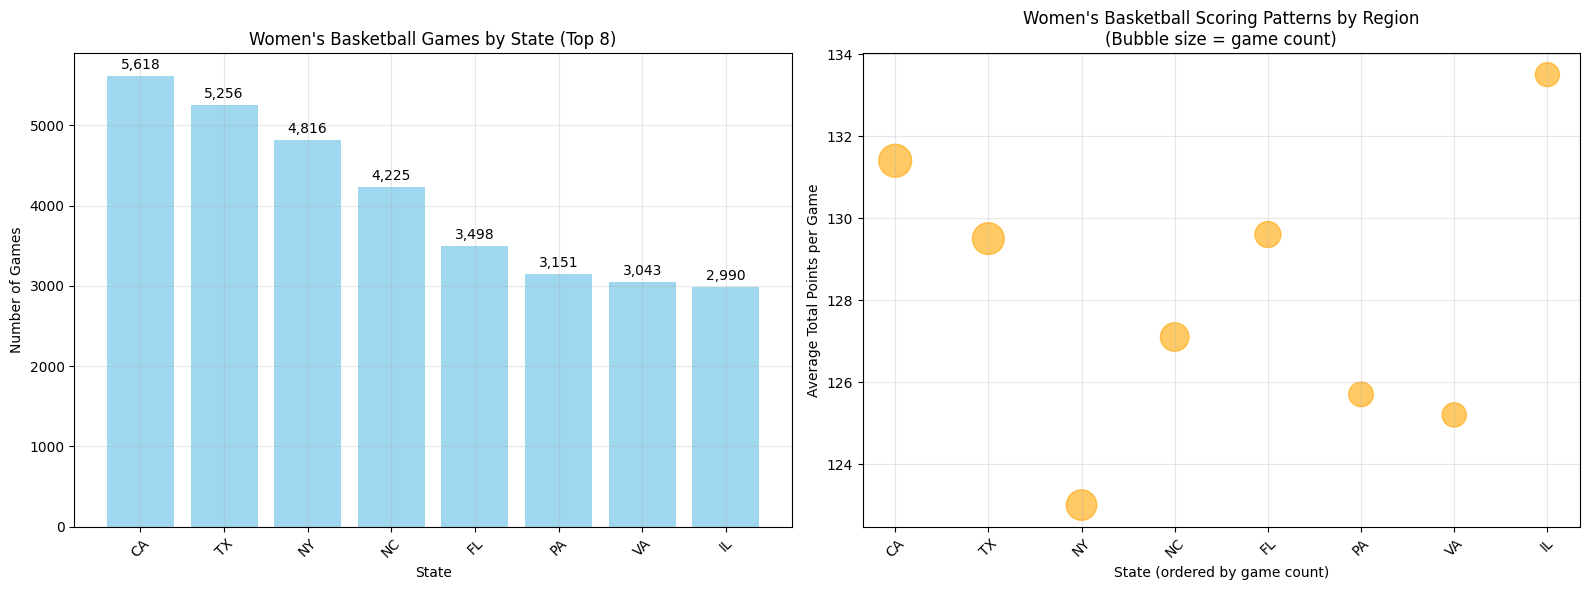

In [165]:
women_regional_results = analyze_regional_game_patterns(women_regular, "Women's Basketball")

REGIONAL GAME ANALYSIS: MEN'S BASKETBALL
Games with city data: 934 / 2,518

TOP 10 STATES BY GAME COUNT:
IN: 96 games (10.3%)
OH: 88 games (9.4%)
CA: 78 games (8.4%)
NY: 57 games (6.1%)
TX: 57 games (6.1%)
NC: 48 games (5.1%)
FL: 42 games (4.5%)
PA: 42 games (4.5%)
MO: 33 games (3.5%)
OK: 30 games (3.2%)

REGIONAL SCORING PATTERNS (States with ≥50 games):
State           Games    Avg Total    Avg Margin  
--------------------------------------------------
IN              96       140.5        11.9        
OH              88       137.3        10.5        
CA              78       139.5        11.9        
NY              57       136.1        11.9        
TX              57       134.8        12.6        


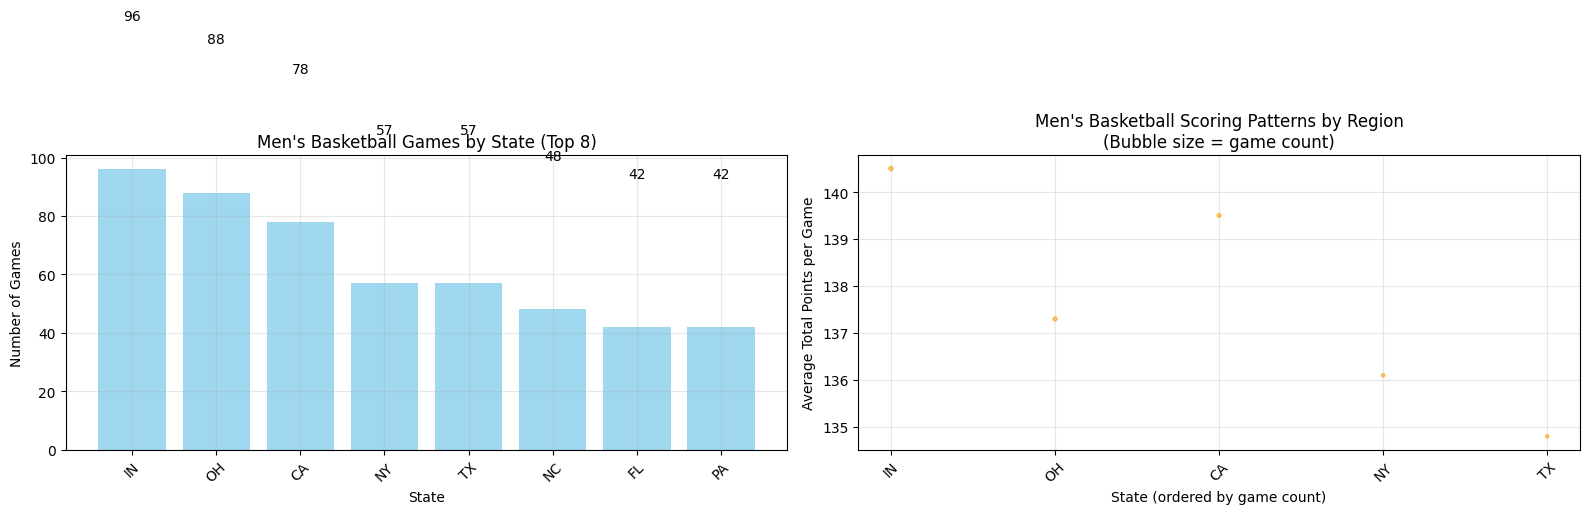

In [166]:
men_regional_results = analyze_regional_game_patterns(men_tourney, "Men's Basketball")

REGIONAL GAME ANALYSIS: WOMEN'S BASKETBALL
Games with city data: 894 / 1,650

TOP 10 STATES BY GAME COUNT:
TX: 147 games (16.4%)
CA: 70 games (7.8%)
NC: 58 games (6.5%)
IN: 53 games (5.9%)
CT: 49 games (5.5%)
KY: 45 games (5.0%)
OH: 43 games (4.8%)
WA: 42 games (4.7%)
IA: 41 games (4.6%)
TN: 33 games (3.7%)

REGIONAL SCORING PATTERNS (States with ≥50 games):
State           Games    Avg Total    Avg Margin  
--------------------------------------------------
TX              147      133.4        18.0        
CA              70       134.4        16.6        
NC              58       133.4        16.4        
IN              53       140.2        16.2        


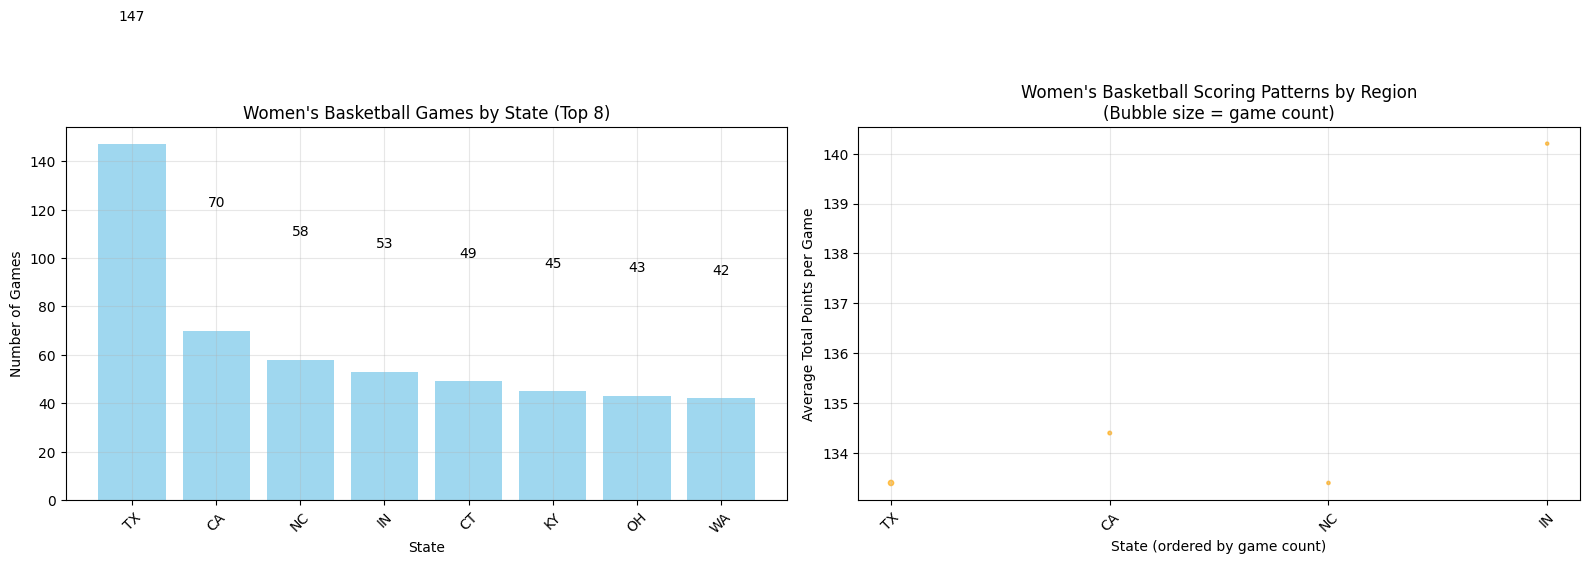

In [162]:
women_regional_results = analyze_regional_game_patterns(women_tourney, "Women's Basketball")